# System

8-qubit, 30-layer, dephasing noise, target Ising.

```JSON
"config":{"run":"vqe","nqubits":8,"state":"dmatrix","output":{"file_name_prefix":"8Q-t20-dephasing","draw":{"status":false,"fig_dpi":100,"type":"png"}},"observable":{"def":"ising","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5,0.5],"bn":[1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0],"r":1}},"ansatz":{"layer":30,"gateset":1,"ugate":{"type":"xy-iss","coefficients":{"cn":[0.5,0.5,0.5,0.5,0.5,0.5,0.5],"bn":[0,0,0,0,0,0,0,0],"r":0},"time":{"min":0.0,"max":20.0}}},"vqe":{"iteration":10,"optimization":{"status":true,"algorithm":"SLSQP","constraint":true}},"init_param":{"value":"random"},"noise_profile":{"status":true,"type":"time-dphasing","noise_prob":[0.001,0.001,0.005,0.001],"noise_on_init_param":{"status":false,"value":0}},"redundant":{"identity_factors":[[0,0,0,0],[1,1,1,1]]},"zne":{"method":"richardson","degree":1,"sampling":"default","data_points":null}}
```

# Imports

In [30]:
# ============================================================
#  Imports
# ============================================================

# --- Standard Libraries ---
import os
import sys
import math
import json
import textwrap
import importlib
from itertools import product as iproduct
from datetime import datetime
from string import Template
from pathlib import Path
from typing import Any, Dict, List, Tuple, Union, Optional
from pprint import pprint
import warnings

# --- Third-Party Libraries ---
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.patches as mpatches
from tabulate import tabulate
from IPython.display import display

# --- Local Modules ---
# Dynamically add `src/` to sys.path (go up two levels)
notebook_dir = Path.cwd()
sys.path.append(str(notebook_dir.parents[2] / "src"))

from nbutils.misc import load_simulation_tree
from nbutils.compile_plot import compile_zne_subplots
from nbutils.zne_plot import plot_zne_result
from nbutils.summarize import summarize_zne_results
from nbutils.export_raw_data_wrapped import export_raw_data_wrapped
from nbutils.master import *

In [31]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams.update({
"font.family":      "serif",
"mathtext.fontset": "dejavuserif",
"axes.linewidth":   0.8,
"xtick.direction":  "in",
"ytick.direction":  "in",
"xtick.top":        True,
"ytick.right":      True,
"xtick.major.size": 4,
"ytick.major.size": 4,
"xtick.minor.size": 2,
"ytick.minor.size": 2,
"xtick.minor.visible": True,
"ytick.minor.visible": True,
"xtick.labelsize":  8,   # ✓ already here
"ytick.labelsize":  8,   # ✓ already here
"axes.labelsize":   8,   # ← add this (xlabel / ylabel)
"legend.fontsize":  8,   # ← add this (legend text)
"font.size":        8,   # ← add this (global fallback)
})

# Variables

In [32]:
# Usage
BASE_DIR = "../REVIEW-EXP-8Q/data"

EXACT_SOL: float = -9.837951447459421

width_px = 2070
height_px = 1571
dpi = 600

FIG_SIZE_IEEE_DOUBLE = (width_px / dpi, height_px / dpi)
MASTER_EXPORT_DIR = "../master-reports/"
OUTPUT_DIR = "reports"

---


In [33]:
RAW_SIM_DATA = load_simulation_tree(BASE_DIR)
RAW_SIM_DATA.keys()

dict_keys(['ZNE', 'VQE', 'VQE_noiseoff'])

# Raw Data Processing Before Plotting

In [34]:
# ============================================================================
# DATA PROCESSING
# ============================================================================

def _process_vqe_noiseoff(content: dict) -> dict:
    nf_folder = content.get("VQE_noiseoff", {})
    nf_costs  = []
    for k, run in nf_folder.items():
        if not run or "REDUNDANT" in k or "output" not in run:
            continue
        try:
            nf_costs.append(run["output"]["optimized_minimum_cost"][0])
        except (KeyError, IndexError, TypeError):
            continue

    stats = {
        "mean": float(np.mean(nf_costs)) if nf_costs else None,
        "std":  float(np.std(nf_costs))  if nf_costs else None,
    }
    print(f"✅ VQE_noiseoff: {len(nf_costs)} runs aggregated, mean={stats['mean']}")
    return stats


def _extract_single_var_run(run: dict) -> tuple | None:
    """
    Extracts from ZNE-single-var runs.

    JSON structure:
        zne_values.others.sorted_noise
        zne_values.others.sorted_expectation_vals
        zne_values.others.beta_coeffiecients   (sic — typo in source JSON)
        zne_values.others.cost_richardson_zne
        zne_values.extrapolated_value
        zne_values.degree
    """
    zne_vals = run["output"].get("zne_values", {})
    others   = zne_vals.get("others", {})

    noise   = others.get("sorted_noise")            or zne_vals.get("sorted_noise")
    y_vals  = others.get("sorted_expectation_vals") or zne_vals.get("sorted_expectation_vals")
    ext_val = zne_vals.get("extrapolated_value")
    betas   = others.get("beta_coeffiecients")      # typo preserved from source JSON
    cost    = others.get("cost_richardson_zne")
    #IMPORTANT:
    # JSON file contains the degree value, but it was never used
    # Always check number of data points used to determine degredd for single-var ZNE
    degree  = len(noise)-1 

    if noise and y_vals and ext_val is not None:
        return noise, y_vals, ext_val, betas, cost, degree
    return None


def _extract_mul_var_run(run: dict) -> tuple | None:
    """
    Extracts from ZNE-mul-var runs.

    JSON structure:
        zne_values.sampled data  : [[n1,n2,n3,val], ...]
        zne_values.extrapolated_value
        zne_values.others.eta_coefficients
        zne_values.degree
    """
    zne_vals = run["output"].get("zne_values", {})
    sampled  = zne_vals.get("sampled data", [])
    ext_val  = zne_vals.get("extrapolated_value")
    degree   = zne_vals.get("degree")

    if not sampled or ext_val is None:
        return None

    noise  = [row[:-1] for row in sampled]
    y_vals = [row[-1]  for row in sampled]

    order  = sorted(range(len(noise)), key=lambda i: sum(noise[i]))
    noise  = [noise[i]  for i in order]
    y_vals = [y_vals[i] for i in order]

    eta  = zne_vals.get("others", {}).get("eta_coefficients") \
        or zne_vals.get("eta_coefficients")
    cost = None
    if eta is not None:
        gamma = sum(abs(e) for e in eta)
        cost  = gamma ** 2

    return noise, y_vals, ext_val, eta, cost, degree


def _process_zne_folder(zne_folder: dict, zne_key: str, nf_stats: dict, extractor) -> dict:
    result = {}

    for label, runs in zne_folder.items():
        ext_vals, all_y_curves = [], []
        all_betas, all_costs   = [], []
        noise_levels = None
        tmax         = None
        noise_type   = None
        degree       = None

        for k, run in runs.items():
            if not run or "REDUNDANT" in k or "output" not in run:
                continue

            extracted = extractor(run)
            if extracted is None:
                print(f"⚠️ Skipping ZNE/{zne_key}/{label}/{k}: Missing required keys.")
                continue

            noise, y_vals, ext_val, betas, cost, degree = extracted
            tmax       = run["config"]["ansatz"]["ugate"]["time"]["max"]
            noise_type = run["config"]["noise_profile"].get("type", "unknown")

            ext_vals.append(ext_val)
            all_y_curves.append(y_vals)
            if betas is not None: all_betas.append(betas)
            if cost  is not None: all_costs.append(cost)
            if noise_levels is None:
                noise_levels = noise

        if ext_vals and all_y_curves:
            y_array = np.array(all_y_curves)
            result[label] = {
                "noise_type":     noise_type,
                "tmax":           tmax,
                "exact_sol":      EXACT_SOL,
                "sorted_noise":   noise_levels,
                "mean_exp_vals":  np.mean(y_array, axis=0).tolist(),
                "std_exp_vals":   np.std(y_array, axis=0).tolist(),
                "zne_mean":       float(np.mean(ext_vals)),
                "zne_std":        float(np.std(ext_vals)),
                "mean_noise_off": nf_stats["mean"],
                "std_noise_off":  nf_stats["std"],
                "degree":         degree if degree is not None else "N/A",
                "order":          degree if degree is not None else "N/A", # Alias
                "beta_mean":      np.mean(all_betas, axis=0).tolist() if all_betas else None,
                "beta_std":       np.std(all_betas,  axis=0).tolist() if all_betas else None,
                "cost_mean":      float(np.mean(all_costs)) if all_costs else None,
                "cost_std":       float(np.std(all_costs))  if all_costs else None,
            }
            print(f"✅ ZNE/{zne_key}/{label}: {len(ext_vals)} runs processed")
        else:
            print(f"❌ Failed to process ZNE/{zne_key}/{label}: No valid runs found")

    return result


def process_for_master_plotting(raw_data: dict) -> dict:
    """
    Main entry point. Expects:

        raw_data/
        └── data/
            ├── VQE/
            ├── VQE_noiseoff/
            └── ZNE/
                ├── ZNE-single-var/
                │   ├── ric2/ ... ricN/
                └── ZNE-mul-var/
                    ├── muld1/ ... muldN/

    Returns:
        {
            "ZNE-single-var": { "ric2": {...}, ... },
            "ZNE-mul-var":    { "muld1": {...}, ... },
        }
    """
    processed = {}
    content   = raw_data.get("data", raw_data)

    # 1. VQE_noiseoff
    nf_stats = _process_vqe_noiseoff(content)

    # 2. ZNE folders
    zne_root = content.get("ZNE", {})
    if not zne_root:
        print("❌ No ZNE folder found in data.")
        return processed

    ZNE_FOLDERS = {
        "ZNE-single-var":                 _extract_single_var_run,
        "ZNE-single-var-learned-folding": _extract_single_var_run,
        "ZNE-mul-var":                    _extract_mul_var_run,
        "ZNE-mul-var-test1":                    _extract_mul_var_run,
        "ZNE-mul-var-test2":                    _extract_mul_var_run,
    }

    for zne_key, extractor in ZNE_FOLDERS.items():
        zne_folder = zne_root.get(zne_key, {})
        if not zne_folder:
            print(f"⚠️ No data found for ZNE/{zne_key}, skipping.")
            continue
        print(f"✅ ZNE/{zne_key} labels found: {list(zne_folder.keys())}")
        processed[zne_key] = _process_zne_folder(zne_folder, zne_key, nf_stats, extractor)

    return processed

In [35]:
# ── Run ────────────────────────────────────────────────────────────────────────
PROCESSED_SIM_DATA = process_for_master_plotting(RAW_SIM_DATA)
PROCESSED_SIM_DATA.keys()

✅ VQE_noiseoff: 10 runs aggregated, mean=-9.624515738915186
⚠️ No data found for ZNE/ZNE-single-var, skipping.
⚠️ No data found for ZNE/ZNE-single-var-learned-folding, skipping.
✅ ZNE/ZNE-mul-var labels found: ['muld2', 'muld1', 'muld3', 'muld4']
✅ ZNE/ZNE-mul-var/muld2: 10 runs processed
✅ ZNE/ZNE-mul-var/muld1: 10 runs processed
✅ ZNE/ZNE-mul-var/muld3: 10 runs processed
✅ ZNE/ZNE-mul-var/muld4: 10 runs processed
⚠️ No data found for ZNE/ZNE-mul-var-test1, skipping.
⚠️ No data found for ZNE/ZNE-mul-var-test2, skipping.


dict_keys(['ZNE-mul-var'])

In [36]:
PROCESSED_SIM_DATA.keys()

dict_keys(['ZNE-mul-var'])

---
## Table/Tools

In [37]:

# ── Helper: convert PROCESSED_SIM_DATA → ordered list ────────────────────────
def build_data_list(processed_sim_data: dict) -> list:
    """
    Converts PROCESSED_SIM_DATA["ZNE-single-var"] into the flat list expected
    by make_zne_table(), ordered from most noise levels (ric7) to fewest (ric2).
    """
    zne_data = processed_sim_data["ZNE-single-var"]
    keys_sorted = sorted(
        zne_data.keys(),
        key=lambda k: len(zne_data[k]["sorted_noise"]),
        reverse=True,
    )
    return [zne_data[k] for k in keys_sorted]


# ── Core table function ───────────────────────────────────────────────────────
def make_zne_table(
    data_list: list,
    fig_width: float,          # final rendered width in inches — required
    dpi: int,                  # output DPI — required
    output_dir: str = "reports",
    filename_stem: str = "zne_table",
    row_height: float = 0.28,  # inches per row; tune to control table height
    fontsize: float = 8,
    save_eps: bool = True,
    save_png: bool = True,
) -> plt.Figure:
    """
    Parameters
    ----------
    data_list : list of dicts
        Each dict must contain:
            sorted_noise   – list of noise levels used
            mean_exp_vals  – list of mean expectation values per noise level
            std_exp_vals   – list of std dev per noise level
            zne_mean       – ZNE extrapolated mean
            zne_std        – ZNE extrapolated std
            mean_noise_off – noise-free estimation mean
            std_noise_off  – noise-free estimation std
        Ordered from most noise levels (ric7) to fewest (ric2).
    fig_width : float
        Final rendered figure width in inches (strictly honoured).
    dpi : int
        Output DPI (strictly honoured). Also sets rcParams for display.
    output_dir : str
        Directory to write output files.
    filename_stem : str
        Base filename without extension.
    row_height : float
        Height of each table row in inches.
    fontsize : float
        Font size for all table text (points).
    save_eps : bool
    save_png : bool

    Returns
    -------
    matplotlib Figure
    """

    # ── Reference entry: most noise levels (first in list) ───────────────────
    ref = data_list[0]

    # ── Build row labels and value strings ────────────────────────────────────
    row_labels = []
    row_values = []

    # Section 1 – Noise-free
    row_labels.append("Noise-free estimation")
    row_values.append(
        f"{ref['mean_noise_off']:.3f} \u00b1 {ref['std_noise_off']:.3f}"
    )

    # Section 2 – Individual noise levels
    for idx, (noise_val, mean_val, std_val) in enumerate(
        zip(ref["sorted_noise"], ref["mean_exp_vals"], ref["std_exp_vals"])
    ):
        label = ("Base noise=" + str(noise_val)) if idx == 0 else ("Boosted noise=" + str(noise_val))
        row_labels.append(label)
        row_values.append(f"{mean_val:.3f} \u00b1 {std_val:.3f}")

    # Section 3 – ZNE values, 2-point → N-point
    for entry in reversed(data_list):
        n_pts = len(entry["sorted_noise"])
        row_labels.append(f"{n_pts}-point Richardson (ric-{n_pts}) ZNE value")
        row_values.append(f"{entry['zne_mean']:.3f} \u00b1 {entry['zne_std']:.3f}")

    # ── Section divider positions ─────────────────────────────────────────────
    n_noise_rows   = len(ref["sorted_noise"])
    section_breaks = [1, 1 + n_noise_rows]

    # ── Figure ────────────────────────────────────────────────────────────────
    n_rows = len(row_labels)
    fig_h  = n_rows * row_height

    matplotlib.rcParams["figure.dpi"] = dpi

    fig, ax = plt.subplots(figsize=(fig_width, fig_h))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_rows)

    # Remove all automatic padding — preserves exact figsize on save.
    # Do NOT use bbox_inches="tight" in savefig; it resizes the canvas.
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    PAD_L = 0.012
    PAD_R = 0.012

    # ── Draw rows ─────────────────────────────────────────────────────────────
    for i, (label, value) in enumerate(zip(row_labels, row_values)):
        y_center = n_rows - i - 0.5
        bold     = (i == 0)

        ax.text(
            PAD_L, y_center, label,
            va="center", ha="left",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
            transform=ax.transData,
        )
        ax.text(
            1 - PAD_R, y_center, value,
            va="center", ha="right",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
            transform=ax.transData,
        )

    # ── Horizontal rules ──────────────────────────────────────────────────────
    ax.axhline(n_rows, color="black", lw=1.0)
    ax.axhline(0,      color="black", lw=1.0)
    for sb in section_breaks:
        ax.axhline(n_rows - sb, color="black", lw=0.6)

    # ── Save ──────────────────────────────────────────────────────────────────
    os.makedirs(output_dir, exist_ok=True)

    if save_eps:
        eps_path = os.path.join(output_dir, f"{filename_stem}.eps")
        fig.savefig(eps_path, format="eps", dpi=dpi)
        print(f"Saved EPS → {eps_path}  |  width={fig.get_figwidth():.4f} in  dpi={dpi}")

    if save_png:
        png_path = os.path.join(output_dir, f"{filename_stem}.png")
        fig.savefig(png_path, format="png", dpi=dpi)
        from PIL import Image
        img = Image.open(png_path)
        print(
            f"Saved PNG → {png_path}  |  "
            f"{img.size[0]}x{img.size[1]} px  "
            f"({img.size[0]/dpi:.4f} x {img.size[1]/dpi:.4f} in at {dpi} dpi)"
        )
    plt.close(fig)
    # ── Generate LaTeX String ────────────────────────────────────────────────
    latex_lines = ["\\hline"]

    # Section 1: Noise-free
    latex_lines.append(
        f"        Noise-free estimation & ${ref['mean_noise_off']:.3f} \\pm {ref['std_noise_off']:.3f} $\\\\"
    )
    latex_lines.append("        \\hline")

    # Section 2: Individual noise levels
    for idx, (noise_val, mean_val, std_val) in enumerate(
        zip(ref["sorted_noise"], ref["mean_exp_vals"], ref["std_exp_vals"])
    ):
        label = f"At base noise $\Lambda_0$" if idx == 0 else f"At $\Lambda_{idx}$"
        latex_lines.append(
            f"        {label} $= {noise_val}$ & ${mean_val:.3f} \\pm {std_val:.3f} $\\\\"
        )
    latex_lines.append("        \\hline")

    # Section 3: ZNE Values (No bold)
    for entry in reversed(data_list):
        n_pts = len(entry["sorted_noise"])
        #label = f"\\text{{{n_pts}-point Richardson (RIC-{n_pts}) ZNE value}}"
        label = f"ZNE of order {n_pts-1}"
        val_str = f"{entry['zne_mean']:.3f} \\pm {entry['zne_std']:.3f}"
        latex_lines.append(f"        {label} & ${val_str}$ \\\\")
    latex_lines.append("        \\hline")

    # Join and print
    latex_output = "\n".join(latex_lines)
    print("\n--- LaTeX Table Code ---")
    print(latex_output)
    print("------------------------\n")

    # Optional: Save to .tex file
    with open(os.path.join(output_dir, f"{filename_stem}.tex"), "w") as f:
        f.write(latex_output)

    return fig

---

# Multivariate ZNE


Original paper: [Quantum error mitigation by layerwise Richardson extrapolation](https://arxiv.org/abs/2402.04000)

## Folding generator


We use identity factors, specifically the number of foldings `[IR, ICZ, IU, IY]`, to generate folded redundant circuits which exhibit higher noise levels.

In [38]:
# l-nariables, order of extrapolation, and noise boost step size
l, d, Delta = 4, 4, 1
ms = [m for m in iproduct(range(d+1), repeat=l) if sum(m) <= d]

lambdas = [[1 + Delta*mi for mi in m] for m in ms]
# [(1,1,1),(1,1,2),(1,1,3),(1,2,1),(1,2,2),(1,3,1),(2,1,1),(2,1,2),(2,2,1),(3,1,1)]
# cond(A) ≈ 30  ← much better
print("Linearly independent identity factors:")
print("Length: ", len(lambdas))
print(lambdas)

Linearly independent identity factors:
Length:  70
[[1, 1, 1, 1], [1, 1, 1, 2], [1, 1, 1, 3], [1, 1, 1, 4], [1, 1, 1, 5], [1, 1, 2, 1], [1, 1, 2, 2], [1, 1, 2, 3], [1, 1, 2, 4], [1, 1, 3, 1], [1, 1, 3, 2], [1, 1, 3, 3], [1, 1, 4, 1], [1, 1, 4, 2], [1, 1, 5, 1], [1, 2, 1, 1], [1, 2, 1, 2], [1, 2, 1, 3], [1, 2, 1, 4], [1, 2, 2, 1], [1, 2, 2, 2], [1, 2, 2, 3], [1, 2, 3, 1], [1, 2, 3, 2], [1, 2, 4, 1], [1, 3, 1, 1], [1, 3, 1, 2], [1, 3, 1, 3], [1, 3, 2, 1], [1, 3, 2, 2], [1, 3, 3, 1], [1, 4, 1, 1], [1, 4, 1, 2], [1, 4, 2, 1], [1, 5, 1, 1], [2, 1, 1, 1], [2, 1, 1, 2], [2, 1, 1, 3], [2, 1, 1, 4], [2, 1, 2, 1], [2, 1, 2, 2], [2, 1, 2, 3], [2, 1, 3, 1], [2, 1, 3, 2], [2, 1, 4, 1], [2, 2, 1, 1], [2, 2, 1, 2], [2, 2, 1, 3], [2, 2, 2, 1], [2, 2, 2, 2], [2, 2, 3, 1], [2, 3, 1, 1], [2, 3, 1, 2], [2, 3, 2, 1], [2, 4, 1, 1], [3, 1, 1, 1], [3, 1, 1, 2], [3, 1, 1, 3], [3, 1, 2, 1], [3, 1, 2, 2], [3, 1, 3, 1], [3, 2, 1, 1], [3, 2, 1, 2], [3, 2, 2, 1], [3, 3, 1, 1], [4, 1, 1, 1], [4, 1, 1, 2], [4, 1, 2, 

We count the number of gates as `[nR, nCZ, nT, nY]` for a given `[IR, ICZ, IU, IY]`.

To transition from the identity factors space to the noise level (gate number) space, we applied a transformation to the noise parameters:

$$(R, nCZ, nT, nY) \to (nR + nY, 2CZ, 7T)$$

Consequently, the number of variables is reduced to 3.

NOTE:

The factors of 2 and 7 (for the CZ and time-evolution gates) do not have any effect on multivariate extrapolation. Since the noise level can be expressed solely in terms of gate counts, these factors were discarded in the manuscript.

In [39]:
# We applied a transformation to noise prameters
# (nR, nCZ, nT, nY)---> (nR+nY, nCZ, nT)
# so the number of variables is reduced to 3
require_point_gate_count_space = math.factorial((l-1) + d) // (math.factorial(l-1) * math.factorial(d))  # combinatorial count of valid m-tuples
print(f"Require points for IFACTORs at order: {d}: ", require_point_gate_count_space)

Require points for IFACTORs at order: 4:  35


In [40]:
print("COPY AND PASTE THESE INTO automate2.py... (GATE_COUNT_SPACE = True)\n")
[[0, 0, 0, 0], *lambdas[:len(lambdas)-1]][:require_point_gate_count_space]


COPY AND PASTE THESE INTO automate2.py... (GATE_COUNT_SPACE = True)



[[0, 0, 0, 0],
 [1, 1, 1, 1],
 [1, 1, 1, 2],
 [1, 1, 1, 3],
 [1, 1, 1, 4],
 [1, 1, 1, 5],
 [1, 1, 2, 1],
 [1, 1, 2, 2],
 [1, 1, 2, 3],
 [1, 1, 2, 4],
 [1, 1, 3, 1],
 [1, 1, 3, 2],
 [1, 1, 3, 3],
 [1, 1, 4, 1],
 [1, 1, 4, 2],
 [1, 1, 5, 1],
 [1, 2, 1, 1],
 [1, 2, 1, 2],
 [1, 2, 1, 3],
 [1, 2, 1, 4],
 [1, 2, 2, 1],
 [1, 2, 2, 2],
 [1, 2, 2, 3],
 [1, 2, 3, 1],
 [1, 2, 3, 2],
 [1, 2, 4, 1],
 [1, 3, 1, 1],
 [1, 3, 1, 2],
 [1, 3, 1, 3],
 [1, 3, 2, 1],
 [1, 3, 2, 2],
 [1, 3, 3, 1],
 [1, 4, 1, 1],
 [1, 4, 1, 2],
 [1, 4, 2, 1]]

In [41]:
[[0, 0, 0, 0], *lambdas] #(GATE_COUNT_SPACE = False)

[[0, 0, 0, 0],
 [1, 1, 1, 1],
 [1, 1, 1, 2],
 [1, 1, 1, 3],
 [1, 1, 1, 4],
 [1, 1, 1, 5],
 [1, 1, 2, 1],
 [1, 1, 2, 2],
 [1, 1, 2, 3],
 [1, 1, 2, 4],
 [1, 1, 3, 1],
 [1, 1, 3, 2],
 [1, 1, 3, 3],
 [1, 1, 4, 1],
 [1, 1, 4, 2],
 [1, 1, 5, 1],
 [1, 2, 1, 1],
 [1, 2, 1, 2],
 [1, 2, 1, 3],
 [1, 2, 1, 4],
 [1, 2, 2, 1],
 [1, 2, 2, 2],
 [1, 2, 2, 3],
 [1, 2, 3, 1],
 [1, 2, 3, 2],
 [1, 2, 4, 1],
 [1, 3, 1, 1],
 [1, 3, 1, 2],
 [1, 3, 1, 3],
 [1, 3, 2, 1],
 [1, 3, 2, 2],
 [1, 3, 3, 1],
 [1, 4, 1, 1],
 [1, 4, 1, 2],
 [1, 4, 2, 1],
 [1, 5, 1, 1],
 [2, 1, 1, 1],
 [2, 1, 1, 2],
 [2, 1, 1, 3],
 [2, 1, 1, 4],
 [2, 1, 2, 1],
 [2, 1, 2, 2],
 [2, 1, 2, 3],
 [2, 1, 3, 1],
 [2, 1, 3, 2],
 [2, 1, 4, 1],
 [2, 2, 1, 1],
 [2, 2, 1, 2],
 [2, 2, 1, 3],
 [2, 2, 2, 1],
 [2, 2, 2, 2],
 [2, 2, 3, 1],
 [2, 3, 1, 1],
 [2, 3, 1, 2],
 [2, 3, 2, 1],
 [2, 4, 1, 1],
 [3, 1, 1, 1],
 [3, 1, 1, 2],
 [3, 1, 1, 3],
 [3, 1, 2, 1],
 [3, 1, 2, 2],
 [3, 1, 3, 1],
 [3, 2, 1, 1],
 [3, 2, 1, 2],
 [3, 2, 2, 1],
 [3, 3, 1, 1],
 [4, 1, 1,

In [42]:
PROCESSED_SIM_DATA["ZNE-mul-var"]["muld1"]

{'noise_type': 'time-dphasing',
 'tmax': 20.0,
 'exact_sol': -9.837951447459421,
 'sorted_noise': [[4, 1.0, 1.0],
  [36, 3.0, 3.0],
  [52, 3.0, 3.0],
  [60, 3.0, 5.0]],
 'mean_exp_vals': [-5.4584013577345285,
  -1.2937001575975031,
  -1.0132983102705608,
  -0.42830411264367163],
 'std_exp_vals': [0.120629367179062,
  0.11461668905195822,
  0.10846528578784398,
  0.07786409881744626],
 'zne_mean': -7.330450572307837,
 'zne_std': 0.13673196093651602,
 'mean_noise_off': -9.624515738915186,
 'std_noise_off': 0.12247894876745011,
 'degree': 1,
 'order': 1,
 'beta_mean': [1.5000000000000002, -1.25, 0.75, 0.0],
 'beta_std': [0.0, 0.0, 0.0, 0.0],
 'cost_mean': 12.25,
 'cost_std': 0.0}

## Main plot

✅ Saved: ../master-reports/RESULT-MULTIVARIATE-RIC-ZNE-VS-ORDER-IEEE.png


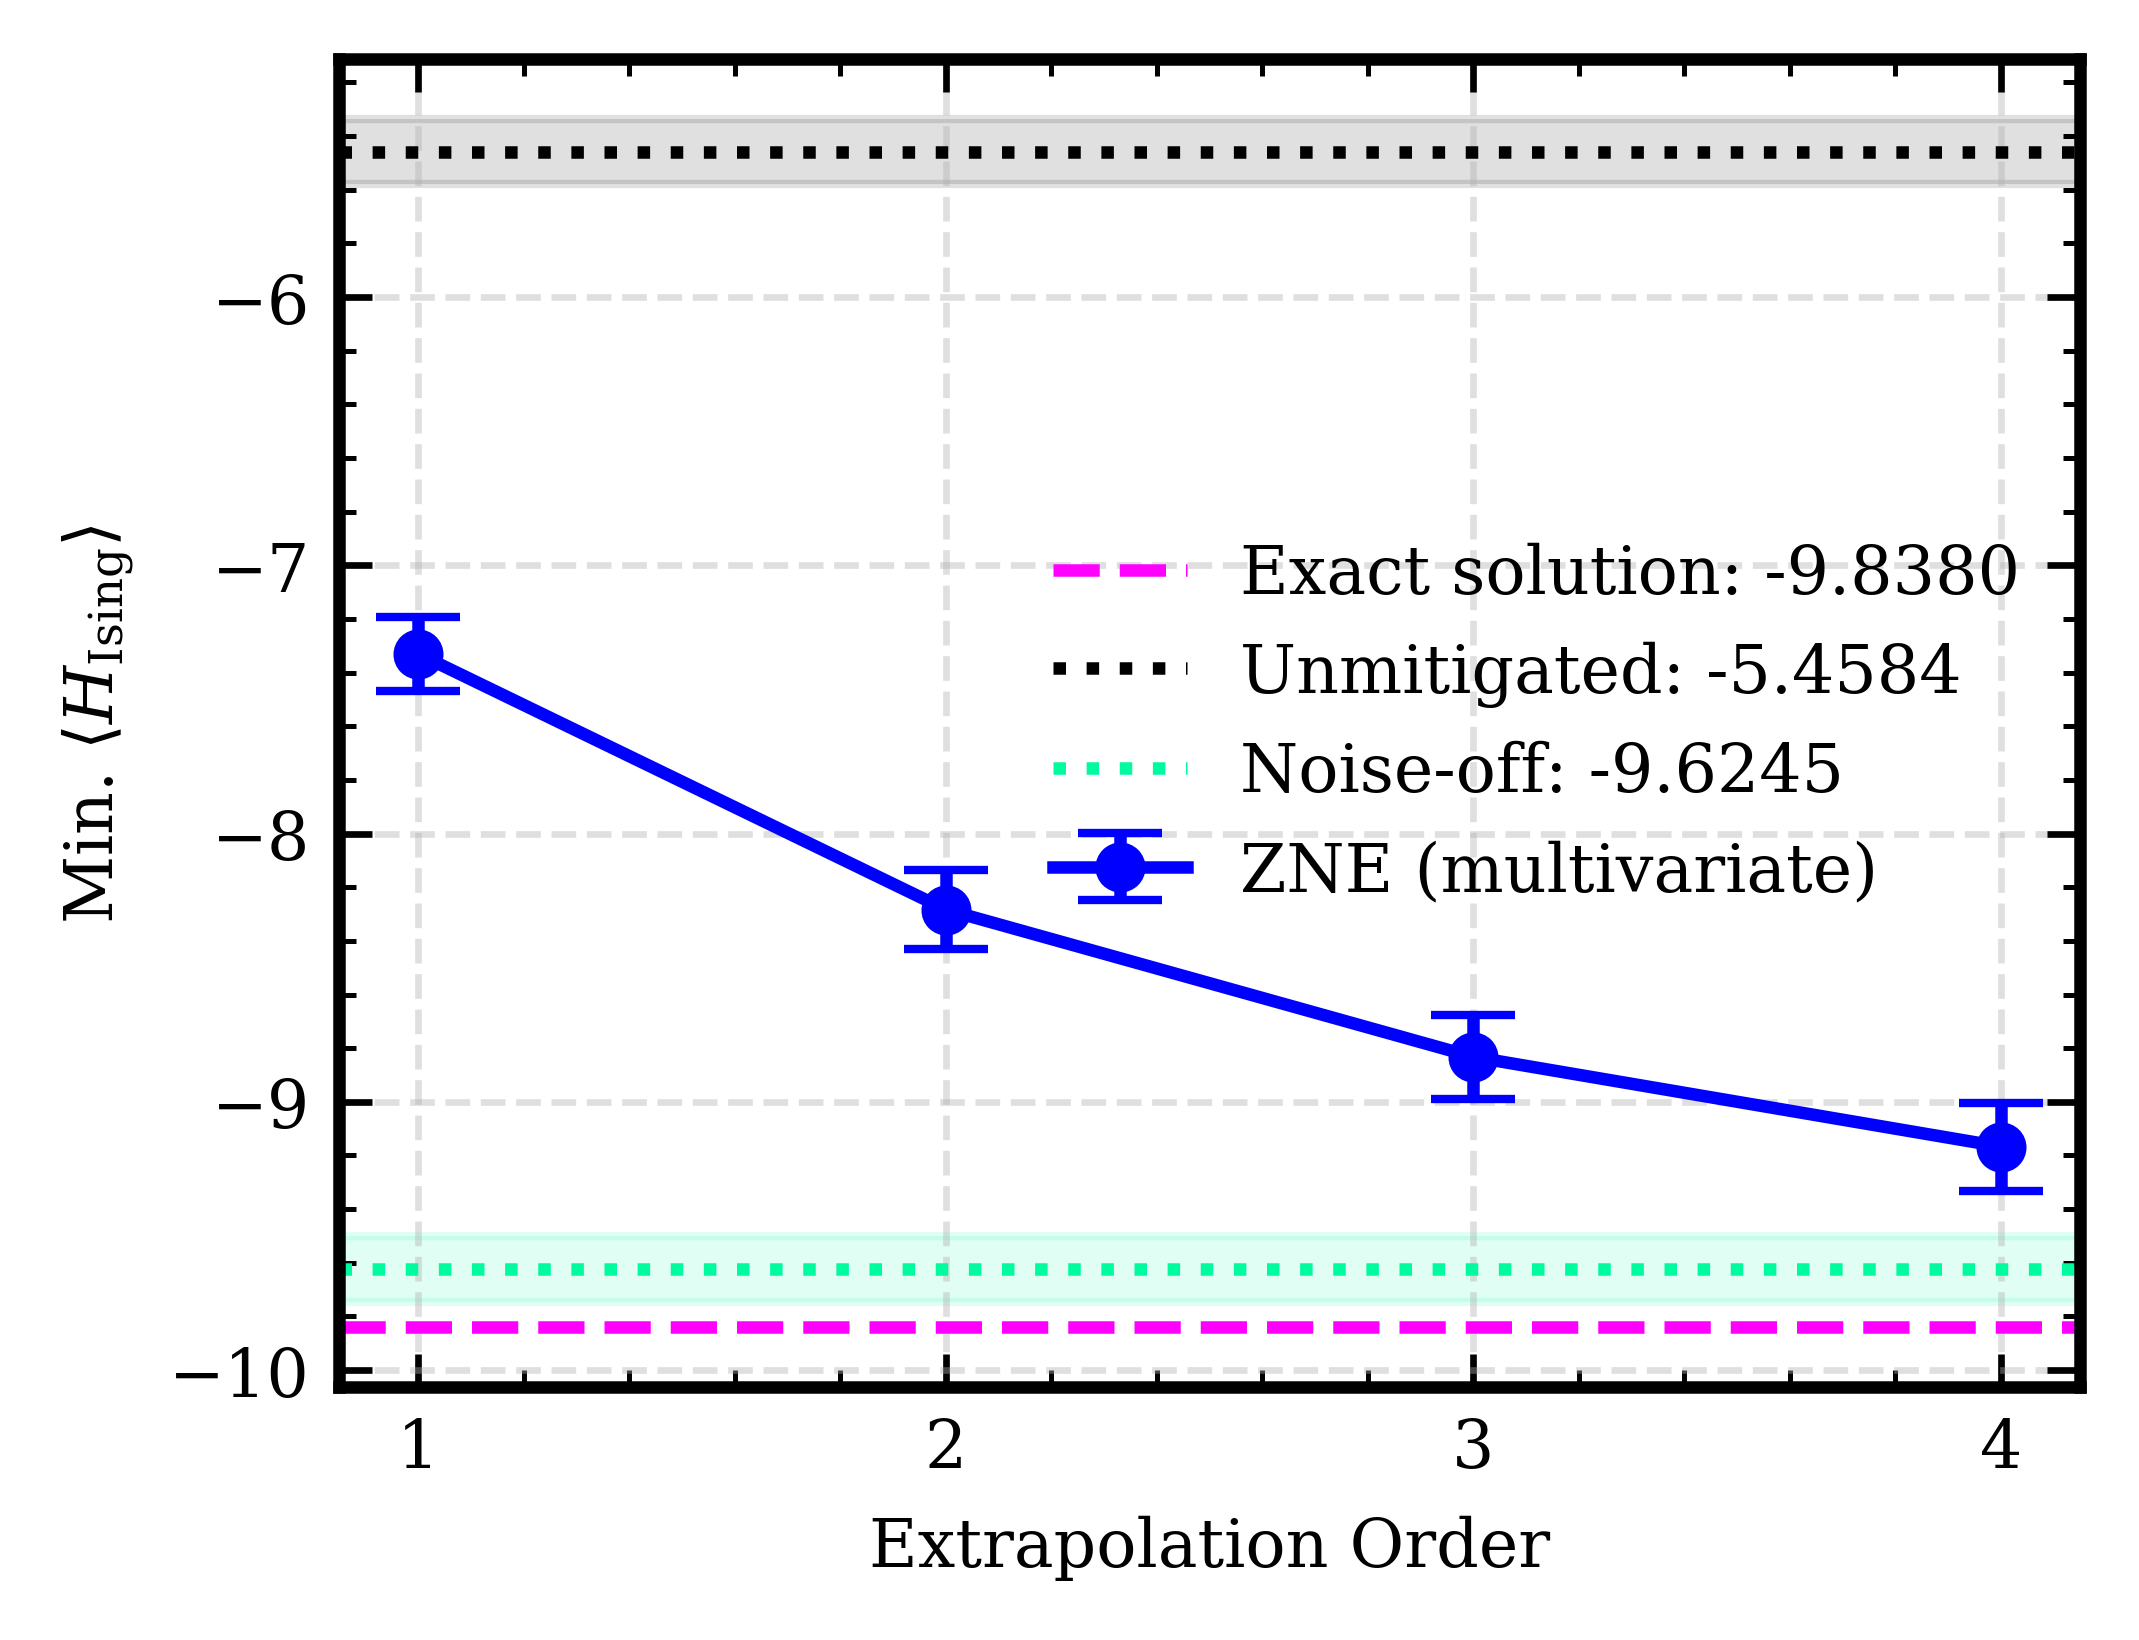

In [43]:
ricmul_plot_zne_vs_degree(
    processed_mul_var = PROCESSED_SIM_DATA["ZNE-mul-var"],
    plot_colors       = {"zne": "#0000ff", "noisy": "black",
                      "exact": "magenta", "noise_off": "#00fb9f", "unmitigated": "black"},
    plot_file_name    = "RESULT-MULTIVARIATE-RIC-ZNE-VS-ORDER-IEEE",
    output_dir        = MASTER_EXPORT_DIR,
    exact_sol         = EXACT_SOL,
    annotate_cost     = False,
    save_format       = "png",
    show_plot      = False,
    dpi                   = 600,
    figsize               = FIG_SIZE_IEEE_DOUBLE,
    tick_fontsize  = 8,
    label_fontsize = 8,
    capsize  = 5,
    marker_size  = 5,
    border_width  = 1.5,
    ylabel = r"Min. $\langle H_{\text{Ising}} \rangle$"
)

---

## Multivariate ZNE Table

### Table/Tools

In [44]:
def make_multivatiate_zne_table(
    data: dict,
    fig_width: float,
    dpi: int,
    output_dir: str = "reports",
    filename_stem: str = "zne_table",
    row_height: float = 0.28,
    fontsize: float = 8,
    save_eps: bool = True,
    save_png: bool = True,
) -> plt.Figure:

    # ── Build row labels and value strings ────────────────────────────────────
    row_labels = []
    row_values = []

    # Section 1 – Noise-free
    row_labels.append("Noise-free estimation")
    row_values.append(
        f"{data['mean_noise_off']:.3f} \u00b1 {data['std_noise_off']:.3f}"
    )

    # Section 2 – Individual noise levels
    for idx, (noise_vec, mean_val, std_val) in enumerate(
        zip(data["sorted_noise"], data["mean_exp_vals"], data["std_exp_vals"])
    ):
        noise_str = str(noise_vec)
        label = ("Base noise=" + noise_str) if idx == 0 else ("Boosted noise=" + noise_str)
        row_labels.append(label)
        row_values.append(f"{mean_val:.3f} \u00b1 {std_val:.3f}")

    # Section 3 – Single ZNE value
    n_pts = len(data["sorted_noise"])
    row_labels.append(f"Multi-variate Richardson ZNE value")
    row_values.append(f"{data['zne_mean']:.3f} \u00b1 {data['zne_std']:.3f}")

    # ── Section divider positions ─────────────────────────────────────────────
    n_noise_rows   = len(data["sorted_noise"])
    section_breaks = [1, 1 + n_noise_rows]

    # ── Figure ────────────────────────────────────────────────────────────────
    n_rows = len(row_labels)
    fig_h  = n_rows * row_height

    matplotlib.rcParams["figure.dpi"] = dpi

    fig, ax = plt.subplots(figsize=(fig_width, fig_h))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_rows)

    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    PAD_L = 0.012
    PAD_R = 0.012

   # ── Draw rows ─────────────────────────────────────────────────────────────
    for i, (label, value) in enumerate(zip(row_labels, row_values)):
        y_center = n_rows - i - 0.5
        bold     = (i == 0)

        # Serial number (skip for first and last rows)
        if i > 0 and i < n_rows - 1:
            ax.text(
                PAD_L, y_center, f"{i}.",
                va="center", ha="left",
                fontsize=fontsize,
                fontweight="normal",
                transform=ax.transData,
            )
            label_x = PAD_L + 0.05  # indent label to make room for number
        else:
            label_x = PAD_L

        ax.text(
            label_x, y_center, label,
            va="center", ha="left",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
            transform=ax.transData,
        )
        ax.text(
            1 - PAD_R, y_center, value,
            va="center", ha="right",
            fontsize=fontsize,
            fontweight="bold" if bold else "normal",
            transform=ax.transData,
        )

    # ── Horizontal rules ──────────────────────────────────────────────────────
    ax.axhline(n_rows, color="black", lw=1.0)
    ax.axhline(0,      color="black", lw=1.0)
    for sb in section_breaks:
        ax.axhline(n_rows - sb, color="black", lw=0.6)

    # ── Save ──────────────────────────────────────────────────────────────────
    os.makedirs(output_dir, exist_ok=True)

    if save_eps:
        eps_path = os.path.join(output_dir, f"{filename_stem}.eps")
        fig.savefig(eps_path, format="eps", dpi=dpi)
        print(f"Saved EPS -> {eps_path}  |  width={fig.get_figwidth():.4f} in  dpi={dpi}")

    if save_png:
        png_path = os.path.join(output_dir, f"{filename_stem}.png")
        fig.savefig(png_path, format="png", dpi=dpi)
        from PIL import Image
        img = Image.open(png_path)
        print(
            f"Saved PNG -> {png_path}  |  "
            f"{img.size[0]}x{img.size[1]} px  "
            f"({img.size[0]/dpi:.4f} x {img.size[1]/dpi:.4f} in at {dpi} dpi)"
        )
    plt.close(fig)

    # ── Generate LaTeX String ─────────────────────────────────────────────────
    latex_lines = ["\\hline"]

    # Section 1: Noise-free
    latex_lines.append(
        f"        Noise-free estimation & ${data['mean_noise_off']:.3f} \\pm {data['std_noise_off']:.3f} $\\\\"
    )
    latex_lines.append("        \\hline")

    # Section 2: Individual noise levels
    for idx, (noise_vec, mean_val, std_val) in enumerate(
        zip(data["sorted_noise"], data["mean_exp_vals"], data["std_exp_vals"])
    ):
        noise_str = str(noise_vec)
        label = "At base noise" if idx == 0 else "At boosted noise"
        latex_lines.append(
            f"        {label} $= {noise_str}$ & ${mean_val:.3f} \\pm {std_val:.3f} $\\\\"
        )
    latex_lines.append("        \\hline")

    # Section 3: ZNE value
    label = f"\\text{{Multi-variate Richardson ZNE value}}"
    val_str = f"{data['zne_mean']:.3f} \\pm {data['zne_std']:.3f}"
    latex_lines.append(f"        {label} & ${val_str}$ \\\\")
    latex_lines.append("        \\hline")

    latex_output = "\n".join(latex_lines)
    print("\n--- LaTeX Table Code ---")
    print(latex_output)
    print("------------------------\n")

    with open(os.path.join(output_dir, f"{filename_stem}.tex"), "w") as f:
        f.write(latex_output)

    return fig

### Degree 1

Saved EPS -> reports/zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/zne-table-mul-var.png  |  2100x648 px  (3.5000 x 1.0800 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.625 \pm 0.122 $\\
        \hline
        At base noise $= [4, 1.0, 1.0]$ & $-5.458 \pm 0.121 $\\
        At boosted noise $= [36, 3.0, 3.0]$ & $-1.294 \pm 0.115 $\\
        At boosted noise $= [52, 3.0, 3.0]$ & $-1.013 \pm 0.108 $\\
        At boosted noise $= [60, 3.0, 5.0]$ & $-0.428 \pm 0.078 $\\
        \hline
        \text{Multi-variate Richardson ZNE value} & $-7.330 \pm 0.137$ \\
        \hline
------------------------



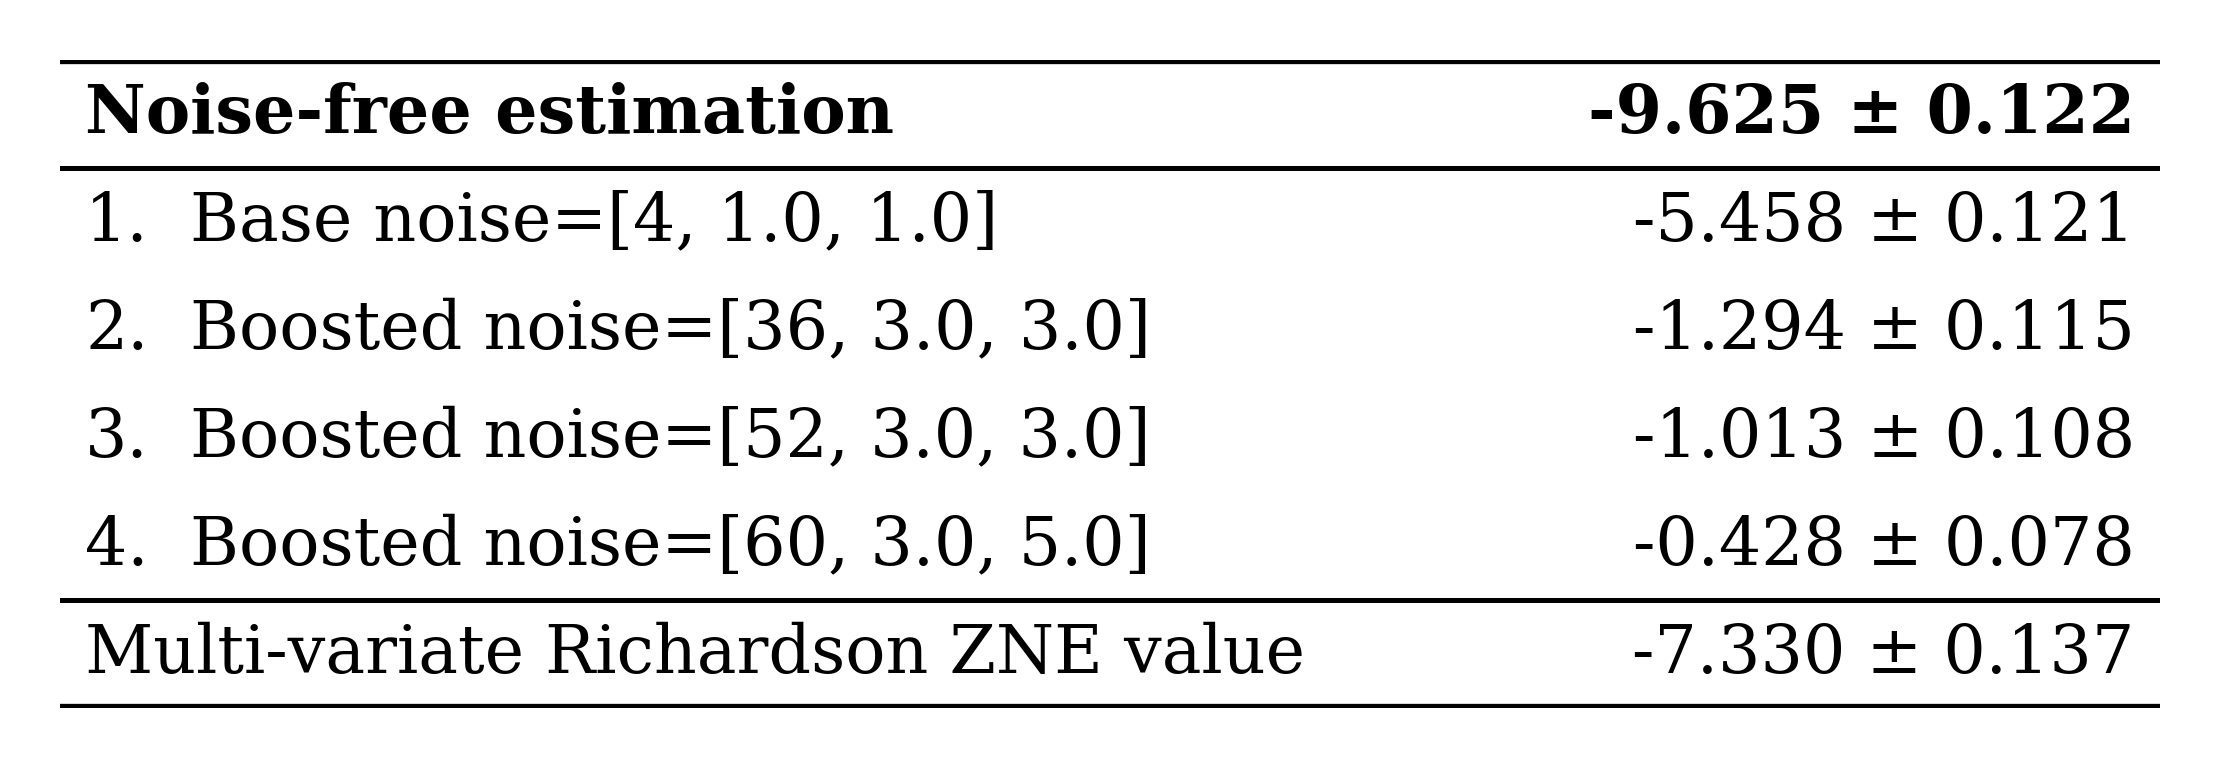

In [45]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["ZNE-mul-var"]["muld1"], output_dir=OUTPUT_DIR, filename_stem="zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 2

Saved EPS -> reports/zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/zne-table-mul-var.png  |  2100x1296 px  (3.5000 x 2.1600 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.625 \pm 0.122 $\\
        \hline
        At base noise $= [4, 1.0, 1.0]$ & $-5.458 \pm 0.121 $\\
        At boosted noise $= [36, 3.0, 3.0]$ & $-1.294 \pm 0.115 $\\
        At boosted noise $= [36, 5.0, 3.0]$ & $-1.222 \pm 0.111 $\\
        At boosted noise $= [52, 3.0, 3.0]$ & $-1.013 \pm 0.108 $\\
        At boosted noise $= [52, 5.0, 3.0]$ & $-0.958 \pm 0.105 $\\
        At boosted noise $= [60, 3.0, 5.0]$ & $-0.428 \pm 0.078 $\\
        At boosted noise $= [60, 5.0, 5.0]$ & $-0.405 \pm 0.075 $\\
        At boosted noise $= [68, 3.0, 3.0]$ & $-0.799 \pm 0.101 $\\
        At boosted noise $= [84, 3.0, 7.0]$ & $-0.160 \pm 0.049 $\\
        At boosted noise $= [92, 3.0, 5.0]$ & $-0.279 \pm 0.065 $\\
        \hline
        \text{Multi-variate Richardson ZNE

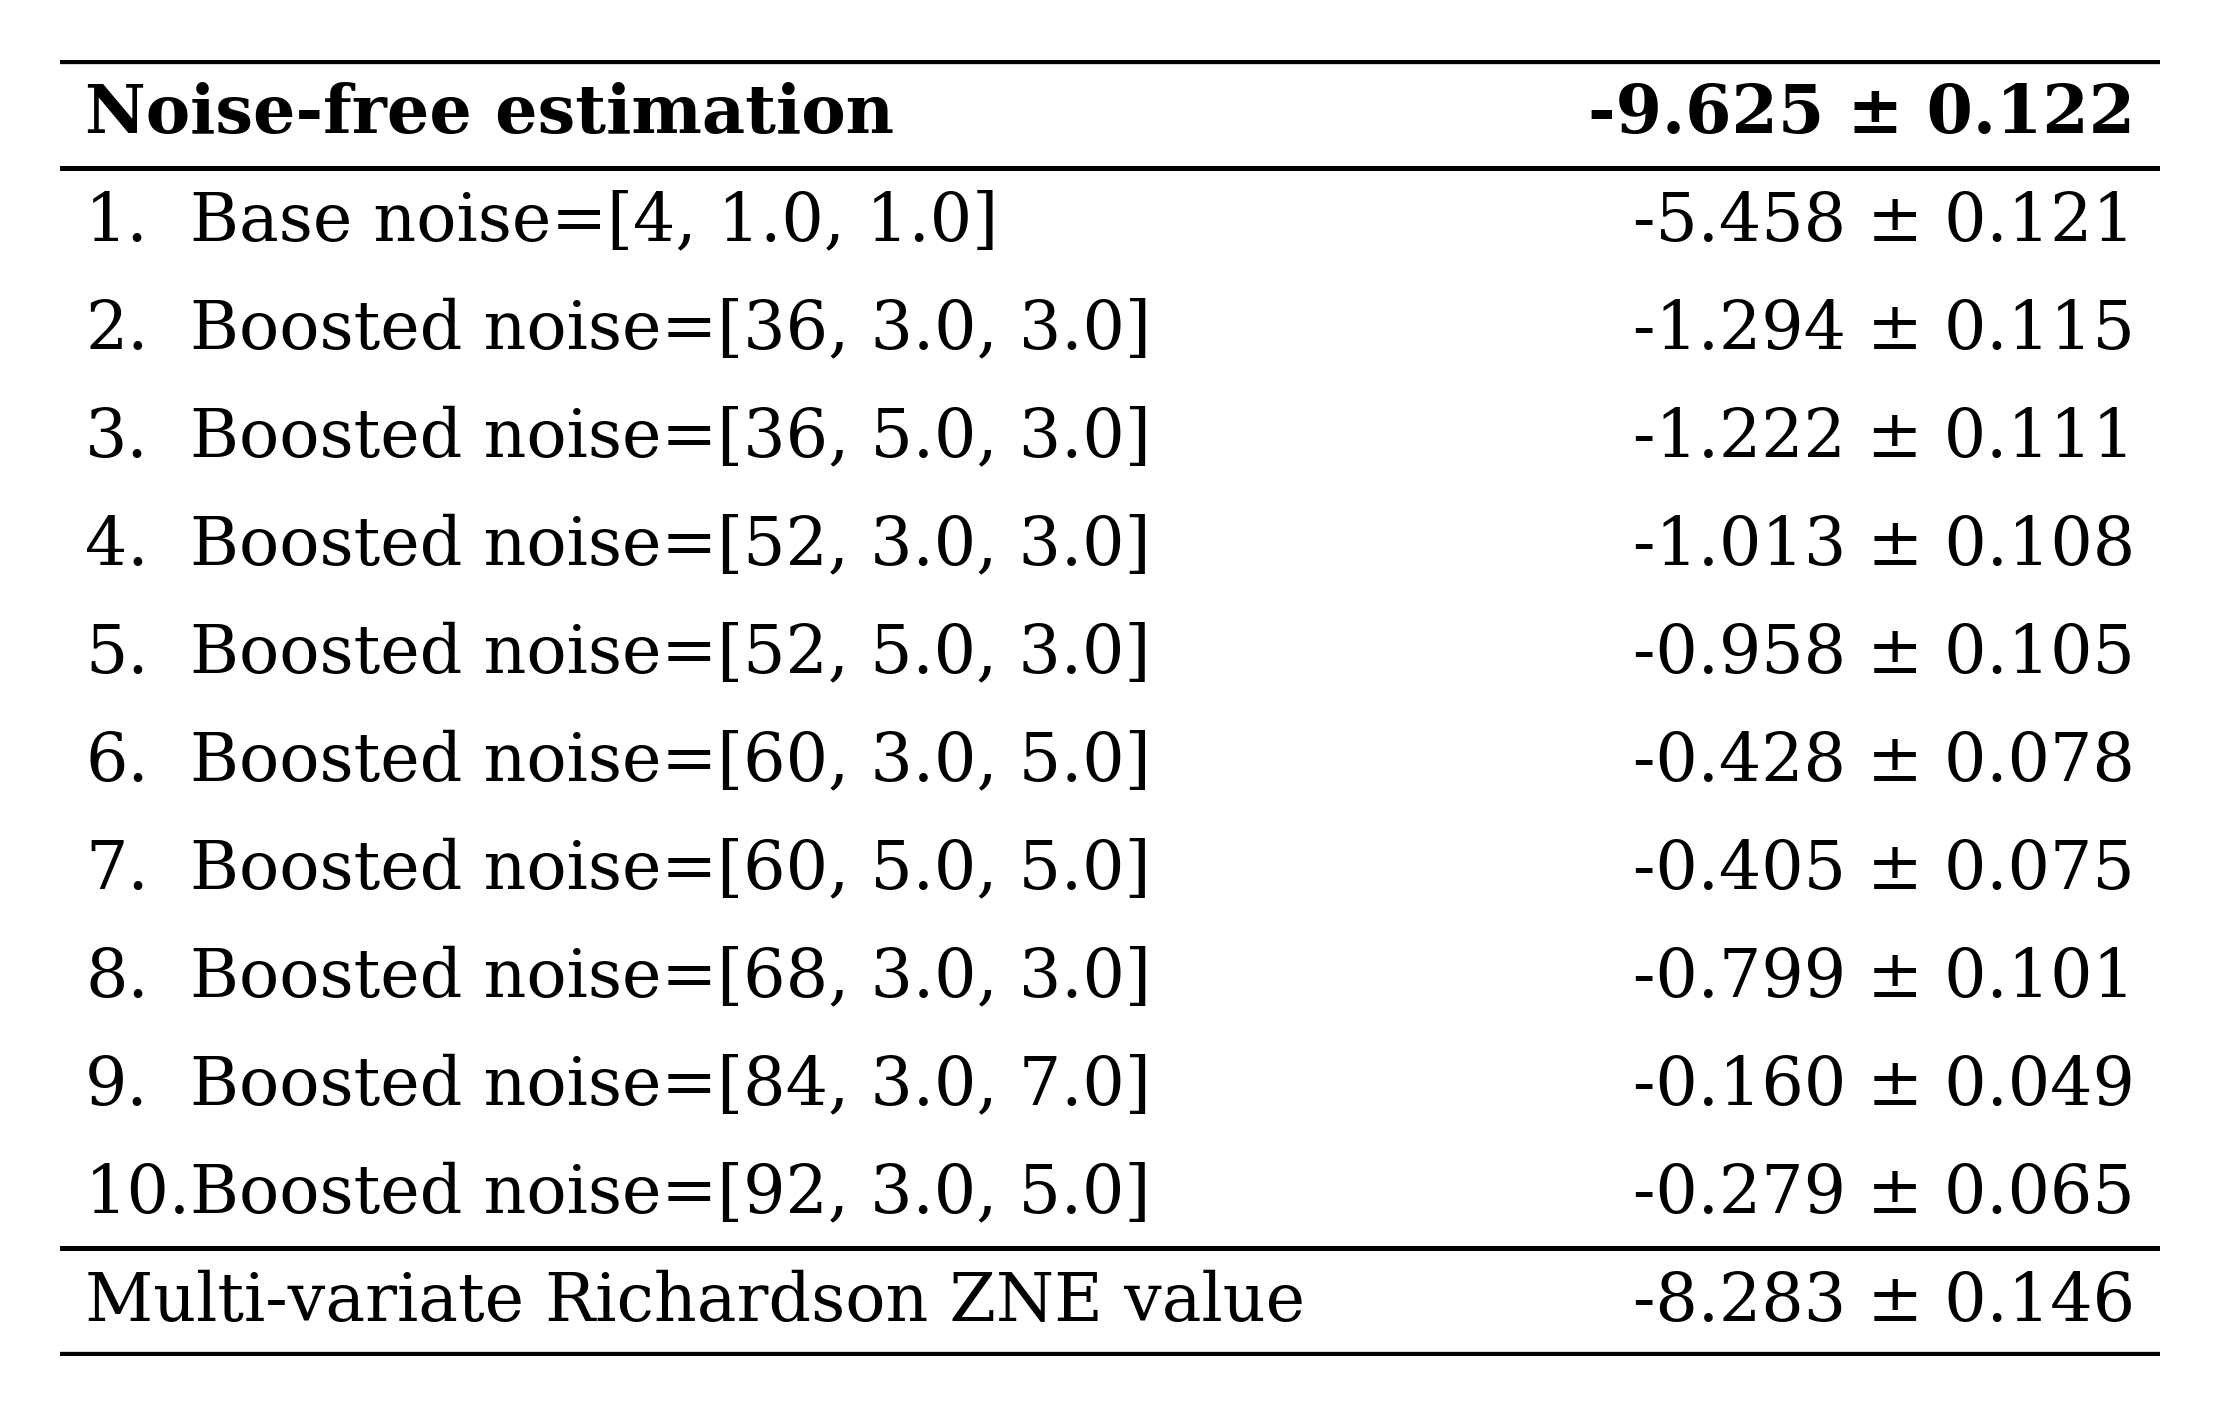

In [46]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["ZNE-mul-var"]["muld2"], output_dir=OUTPUT_DIR, filename_stem="zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 3

Saved EPS -> reports/zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/zne-table-mul-var.png  |  2100x2376 px  (3.5000 x 3.9600 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.625 \pm 0.122 $\\
        \hline
        At base noise $= [4, 1.0, 1.0]$ & $-5.458 \pm 0.121 $\\
        At boosted noise $= [36, 3.0, 3.0]$ & $-1.294 \pm 0.115 $\\
        At boosted noise $= [36, 5.0, 3.0]$ & $-1.222 \pm 0.111 $\\
        At boosted noise $= [36, 7.0, 3.0]$ & $-1.155 \pm 0.108 $\\
        At boosted noise $= [52, 3.0, 3.0]$ & $-1.013 \pm 0.108 $\\
        At boosted noise $= [52, 5.0, 3.0]$ & $-0.958 \pm 0.105 $\\
        At boosted noise $= [52, 7.0, 3.0]$ & $-0.906 \pm 0.102 $\\
        At boosted noise $= [60, 3.0, 5.0]$ & $-0.428 \pm 0.078 $\\
        At boosted noise $= [60, 5.0, 5.0]$ & $-0.405 \pm 0.075 $\\
        At boosted noise $= [60, 7.0, 5.0]$ & $-0.384 \pm 0.073 $\\
        At boosted noise $= [68, 3.0, 3.0]$ & $-0.799 \pm

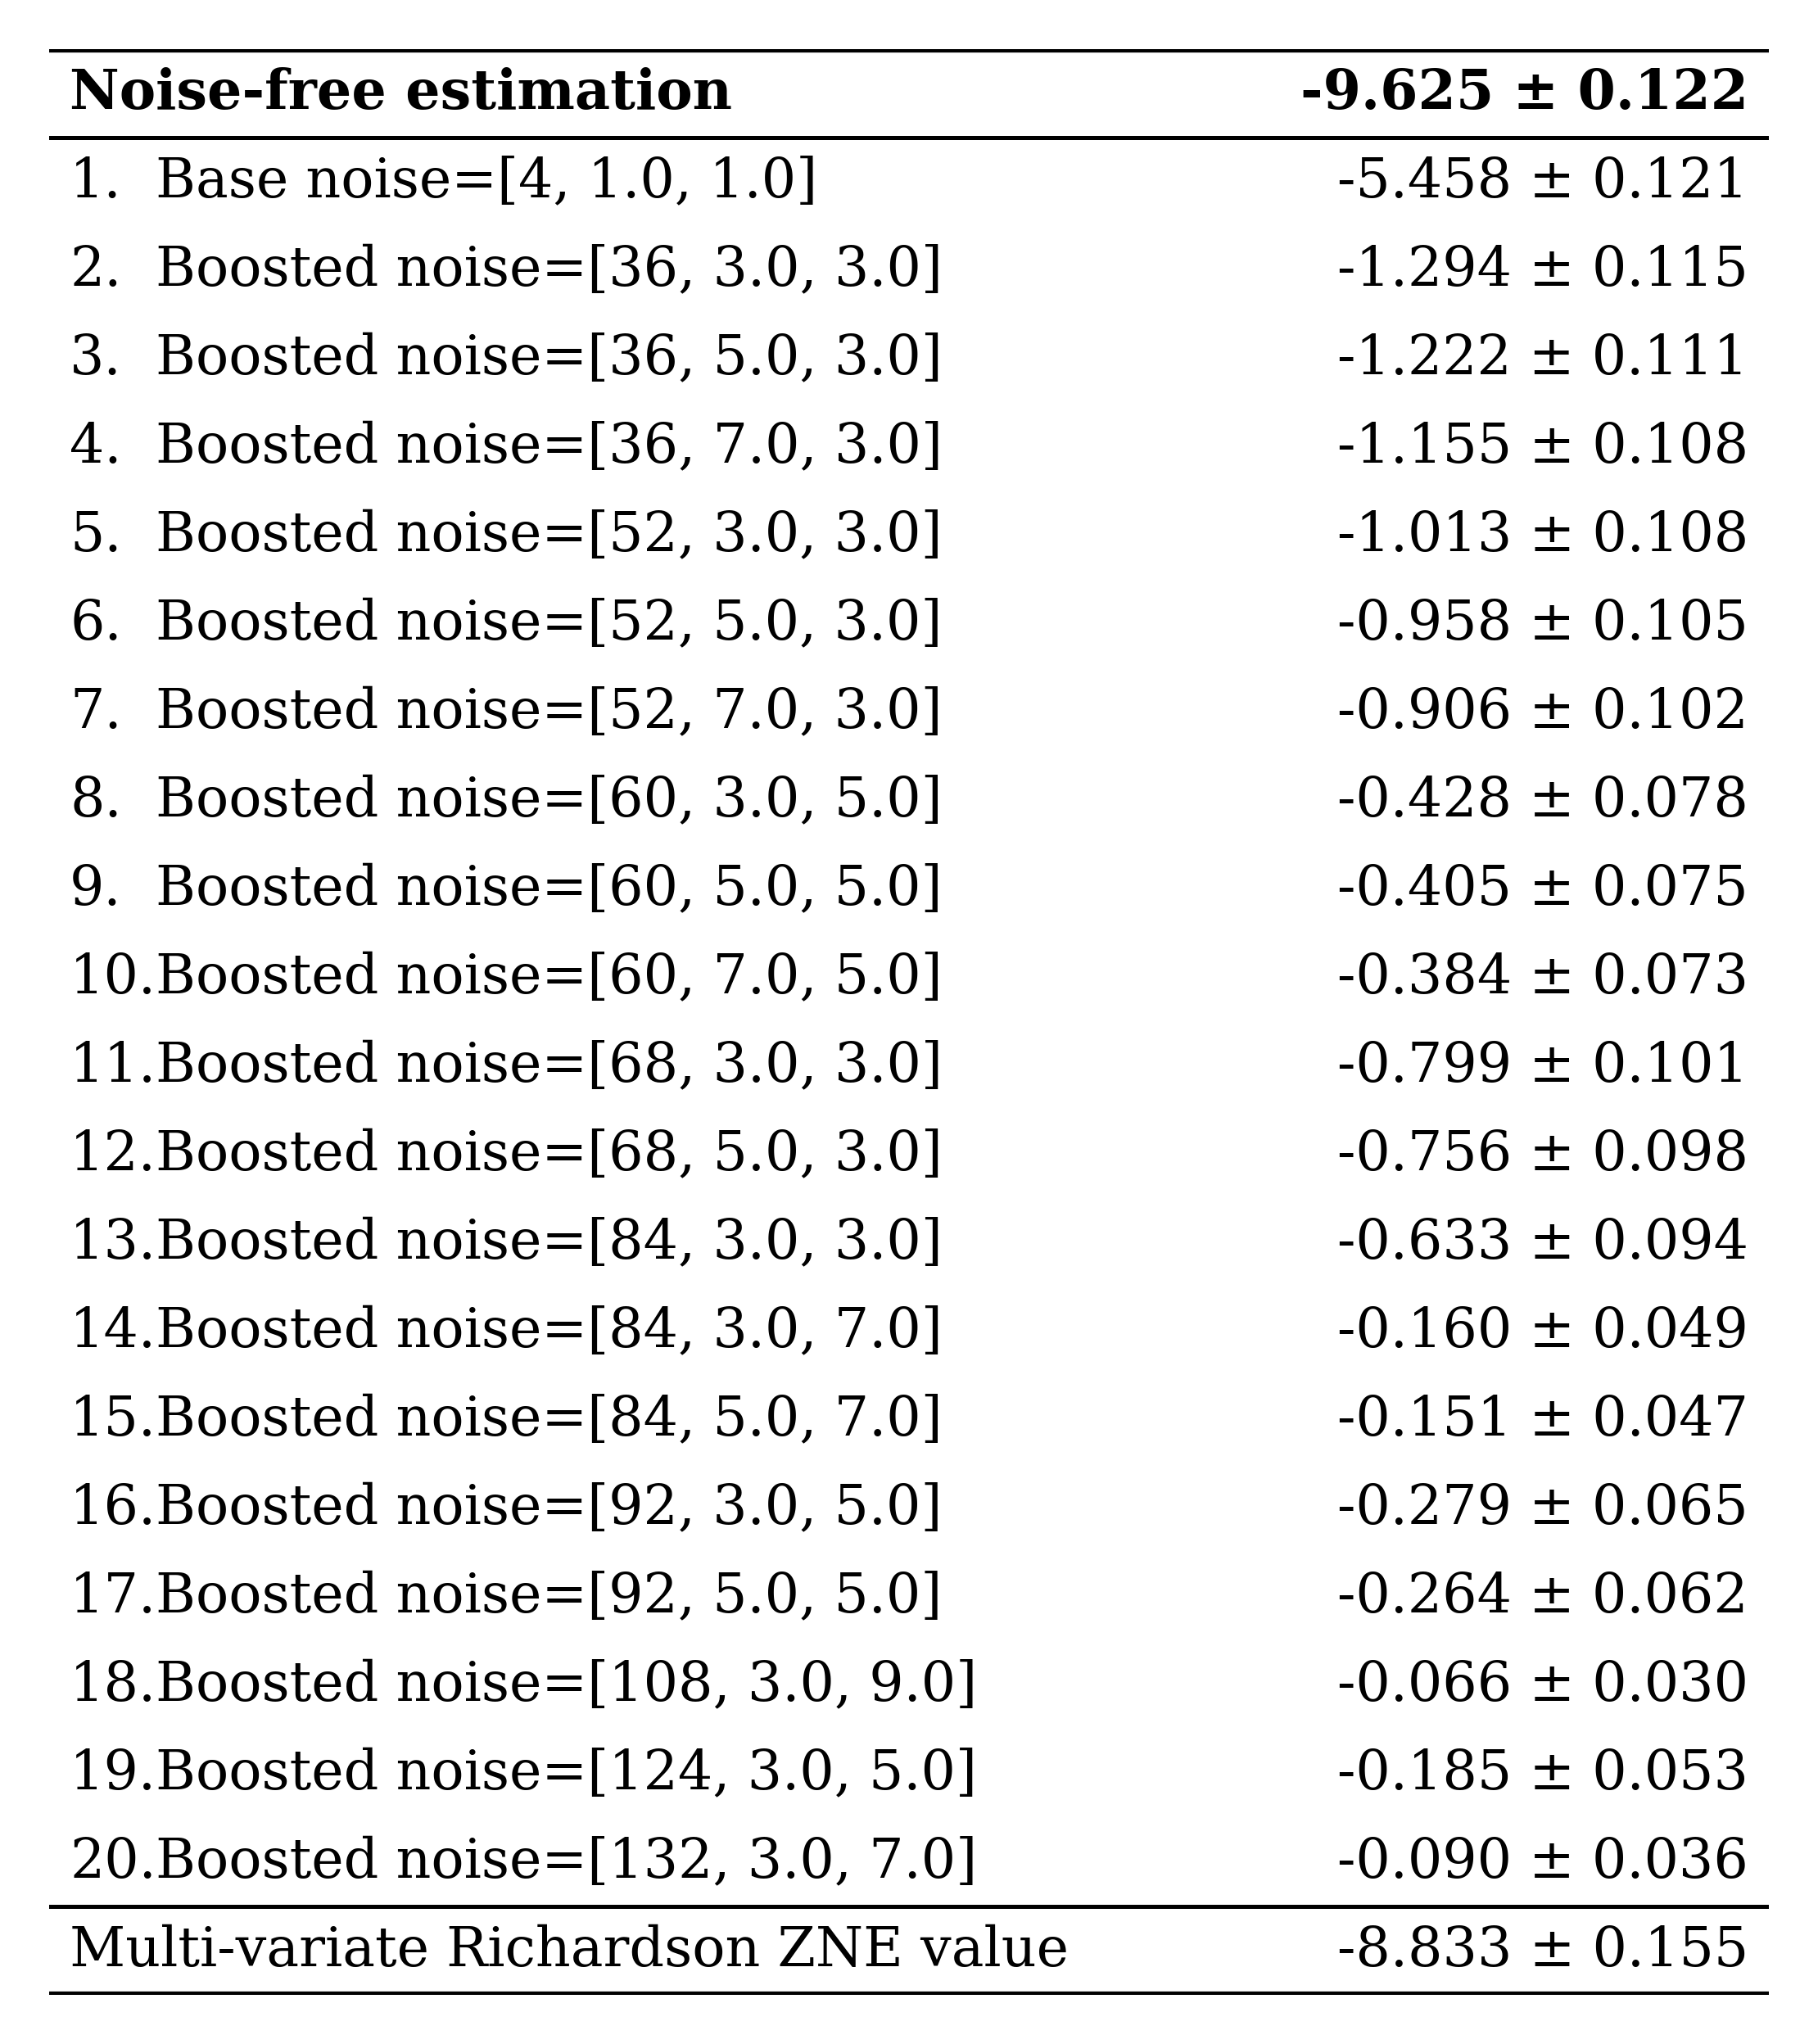

In [47]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["ZNE-mul-var"]["muld3"], output_dir=OUTPUT_DIR, filename_stem="zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

### Degree 4

Saved EPS -> reports/zne-table-mul-var.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/zne-table-mul-var.png  |  2100x3996 px  (3.5000 x 6.6600 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Noise-free estimation & $-9.625 \pm 0.122 $\\
        \hline
        At base noise $= [4, 1.0, 1.0]$ & $-5.458 \pm 0.121 $\\
        At boosted noise $= [36, 3.0, 3.0]$ & $-1.294 \pm 0.115 $\\
        At boosted noise $= [36, 5.0, 3.0]$ & $-1.222 \pm 0.111 $\\
        At boosted noise $= [36, 7.0, 3.0]$ & $-1.155 \pm 0.108 $\\
        At boosted noise $= [36, 9.0, 3.0]$ & $-1.093 \pm 0.104 $\\
        At boosted noise $= [52, 3.0, 3.0]$ & $-1.013 \pm 0.108 $\\
        At boosted noise $= [52, 5.0, 3.0]$ & $-0.958 \pm 0.105 $\\
        At boosted noise $= [52, 7.0, 3.0]$ & $-0.906 \pm 0.102 $\\
        At boosted noise $= [52, 9.0, 3.0]$ & $-0.857 \pm 0.099 $\\
        At boosted noise $= [60, 3.0, 5.0]$ & $-0.428 \pm 0.078 $\\
        At boosted noise $= [60, 5.0, 5.0]$ & $-0.405 \pm

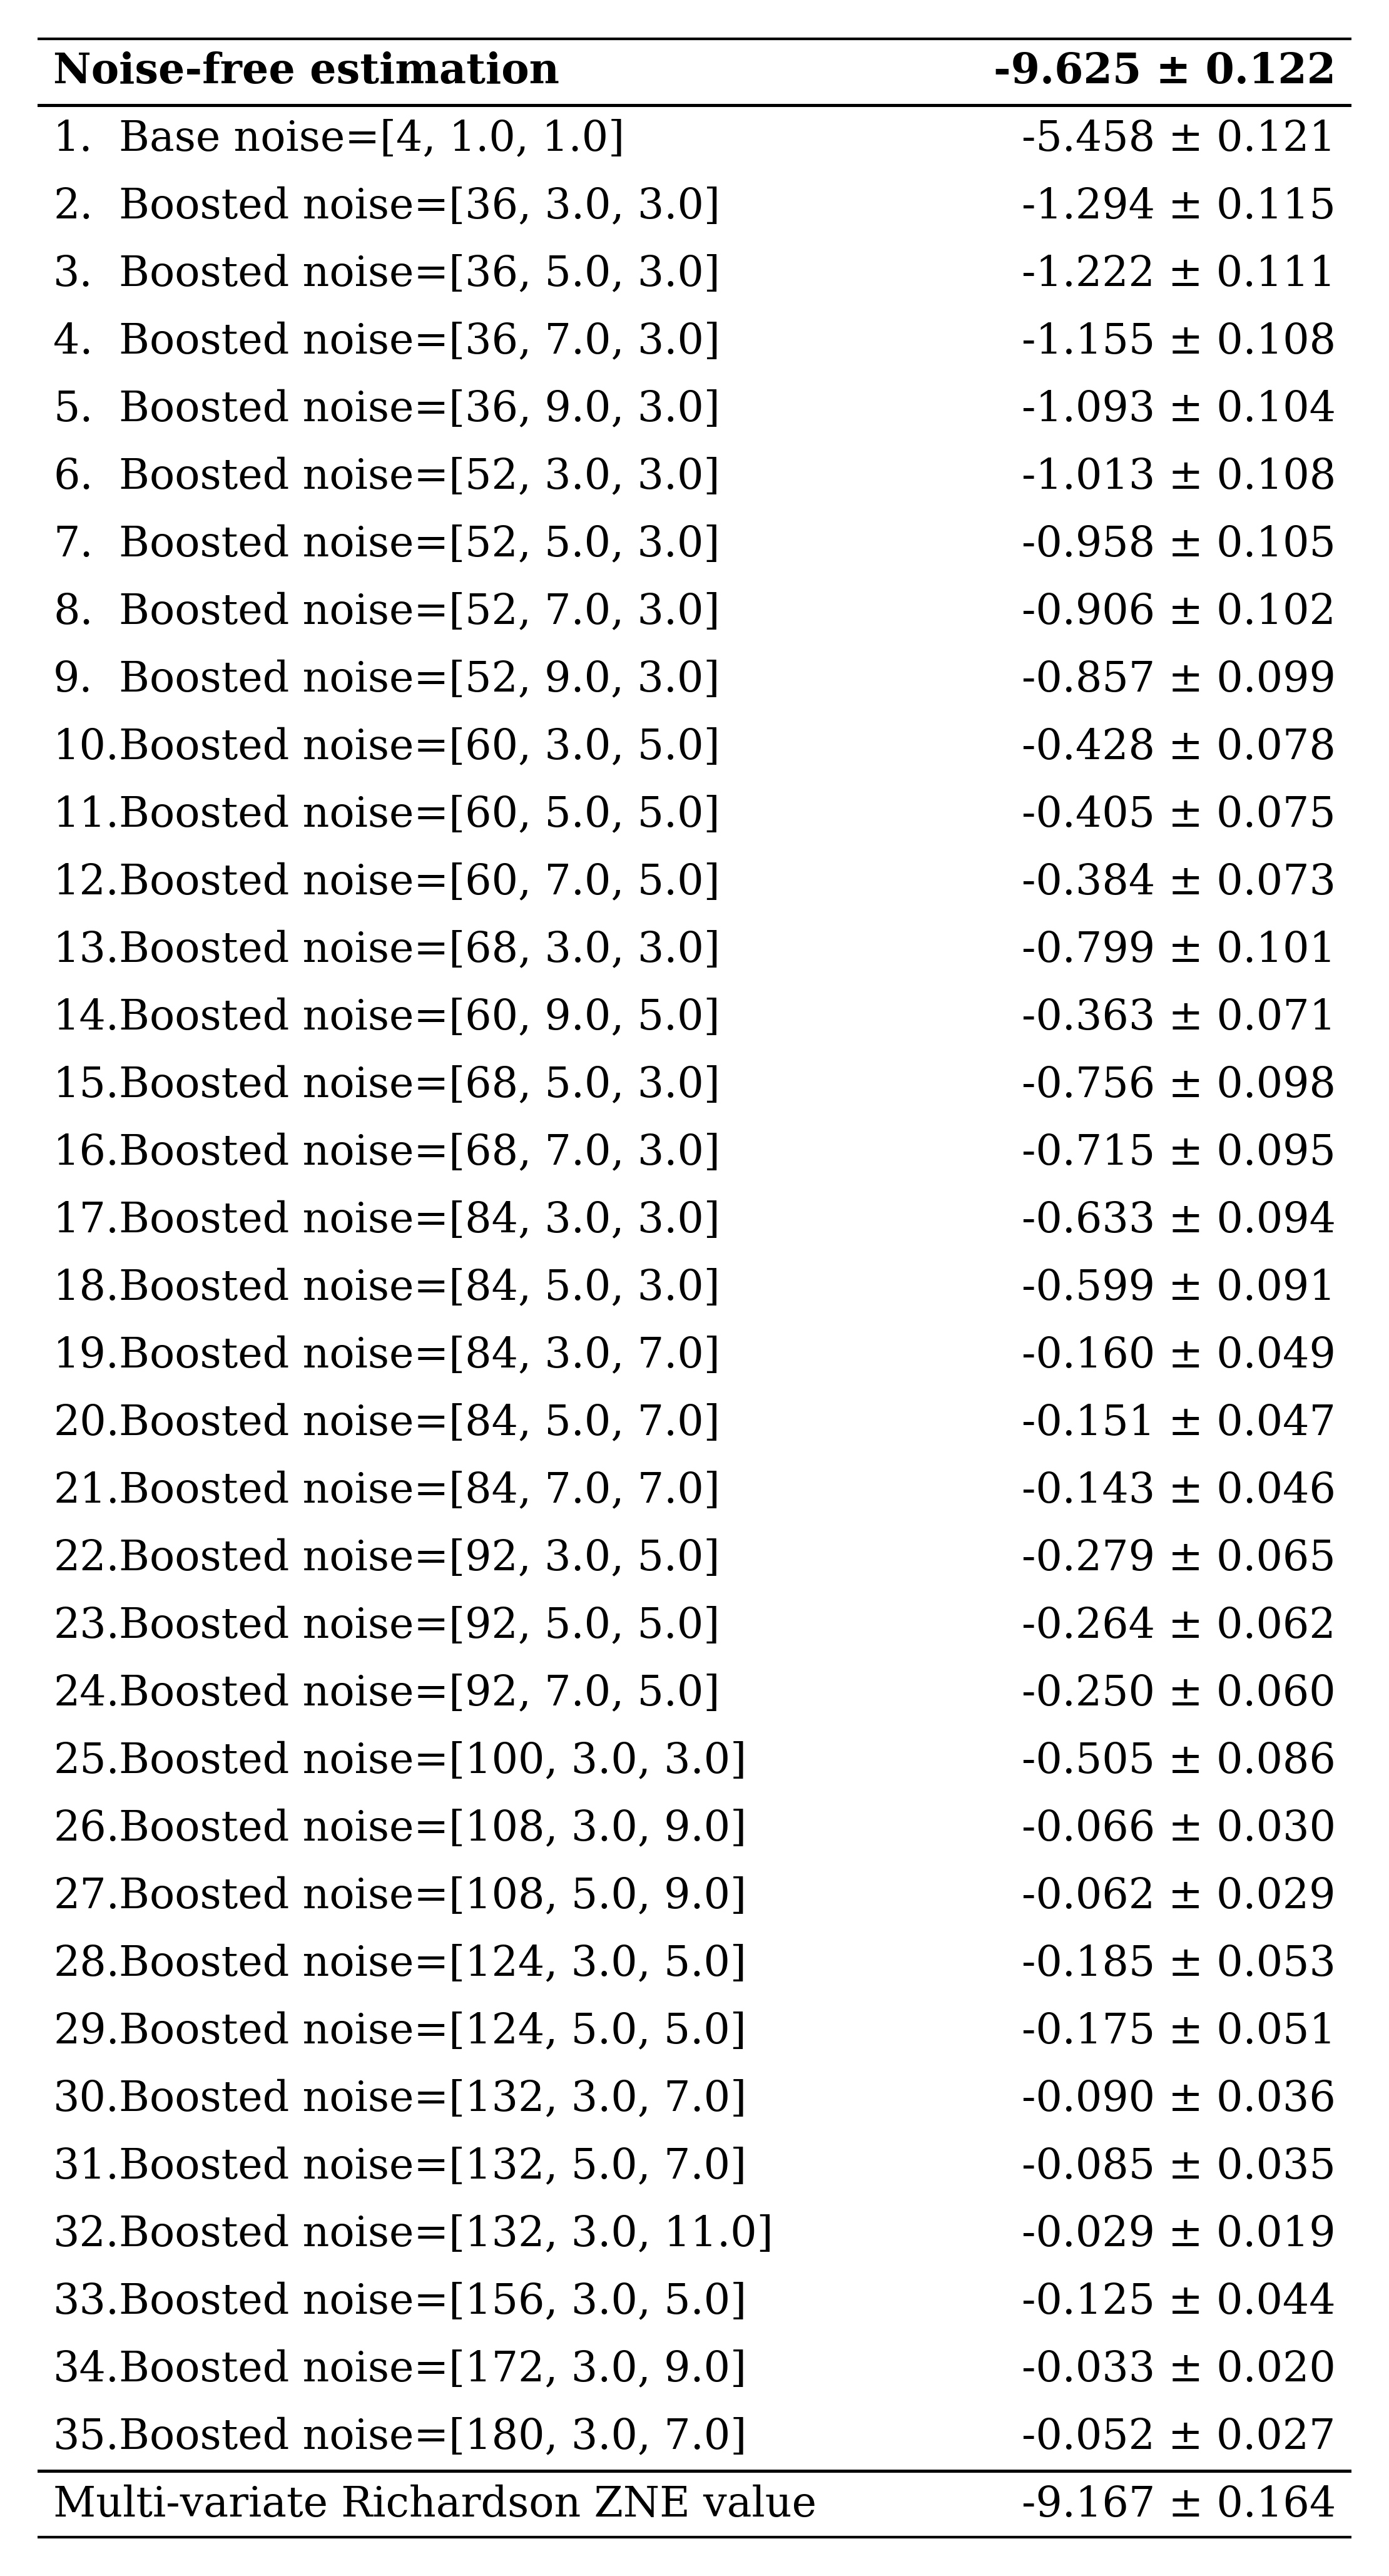

In [48]:
make_multivatiate_zne_table(PROCESSED_SIM_DATA["ZNE-mul-var"]["muld4"], output_dir=OUTPUT_DIR, filename_stem="zne-table-mul-var", fontsize = 8, row_height = 0.18, fig_width=3.5, dpi=600)

In [49]:
def make_zne_order_table(
    mul_var_data: dict,          # PROCESSED_SIM_DATA["ZNE-mul-var"]
    fig_width: float,
    dpi: int,
    output_dir: str = "reports",
    filename_stem: str = "zne_order_table",
    row_height: float = 0.28,
    fontsize: float = 8,
    save_eps: bool = True,
    save_png: bool = True,
) -> plt.Figure:

    # ── Sort entries by degree field ─────────────────────────────────────────
    sorted_keys = sorted(mul_var_data.keys(), key=lambda k: mul_var_data[k]["degree"])

    # ── Build row labels and value strings ───────────────────────────────────
    row_labels = []
    row_values = []

    for key in sorted_keys:
        entry = mul_var_data[key]
        degree = entry["degree"]
        row_labels.append(f"{key} (degree {degree})")
        row_values.append(
            f"{entry['zne_mean']:.3f} \u00b1 {entry['zne_std']:.3f}"
        )

    # ── Figure ───────────────────────────────────────────────────────────────
    n_rows = len(row_labels)
    fig_h  = n_rows * row_height

    matplotlib.rcParams["figure.dpi"] = dpi

    fig, ax = plt.subplots(figsize=(fig_width, fig_h))
    ax.set_axis_off()
    ax.set_xlim(0, 1)
    ax.set_ylim(0, n_rows)

    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

    PAD_L = 0.012
    PAD_R = 0.012

    # ── Draw rows ────────────────────────────────────────────────────────────
    for i, (label, value) in enumerate(zip(row_labels, row_values)):
        y_center = n_rows - i - 0.5

        ax.text(
            PAD_L, y_center, label,
            va="center", ha="left",
            fontsize=fontsize,
            fontweight="normal",
            transform=ax.transData,
        )
        ax.text(
            1 - PAD_R, y_center, value,
            va="center", ha="right",
            fontsize=fontsize,
            fontweight="normal",
            transform=ax.transData,
        )

    # ── Horizontal rules ─────────────────────────────────────────────────────
    ax.axhline(n_rows, color="black", lw=1.0)
    ax.axhline(0,      color="black", lw=1.0)

    # ── Save ─────────────────────────────────────────────────────────────────
    os.makedirs(output_dir, exist_ok=True)

    if save_eps:
        eps_path = os.path.join(output_dir, f"{filename_stem}.eps")
        fig.savefig(eps_path, format="eps", dpi=dpi)
        print(f"Saved EPS -> {eps_path}  |  width={fig.get_figwidth():.4f} in  dpi={dpi}")

    if save_png:
        png_path = os.path.join(output_dir, f"{filename_stem}.png")
        fig.savefig(png_path, format="png", dpi=dpi)
        from PIL import Image
        img = Image.open(png_path)
        print(
            f"Saved PNG -> {png_path}  |  "
            f"{img.size[0]}x{img.size[1]} px  "
            f"({img.size[0]/dpi:.4f} x {img.size[1]/dpi:.4f} in at {dpi} dpi)"
        )
    plt.close(fig)

    # ── Generate LaTeX String ────────────────────────────────────────────────
    latex_lines = ["\\hline"]

    for key in sorted_keys:
        entry = mul_var_data[key]
        degree = entry["degree"]
        label = f"Order {degree}"
        val_str = f"{entry['zne_mean']:.3f} \\pm {entry['zne_std']:.3f}"
        latex_lines.append(f"        {label} & ${val_str}$ \\\\")

    latex_lines.append("        \\hline")

    latex_output = "\n".join(latex_lines)
    print("\n--- LaTeX Table Code ---")
    print(latex_output)
    print("------------------------\n")

    with open(os.path.join(output_dir, f"{filename_stem}.tex"), "w") as f:
        f.write(latex_output)

    return fig

Saved EPS -> reports/zne_order_table.eps  |  width=3.5000 in  dpi=600
Saved PNG -> reports/zne_order_table.png  |  2100x432 px  (3.5000 x 0.7200 in at 600 dpi)

--- LaTeX Table Code ---
\hline
        Order 1 & $-7.330 \pm 0.137$ \\
        Order 2 & $-8.283 \pm 0.146$ \\
        Order 3 & $-8.833 \pm 0.155$ \\
        Order 4 & $-9.167 \pm 0.164$ \\
        \hline
------------------------



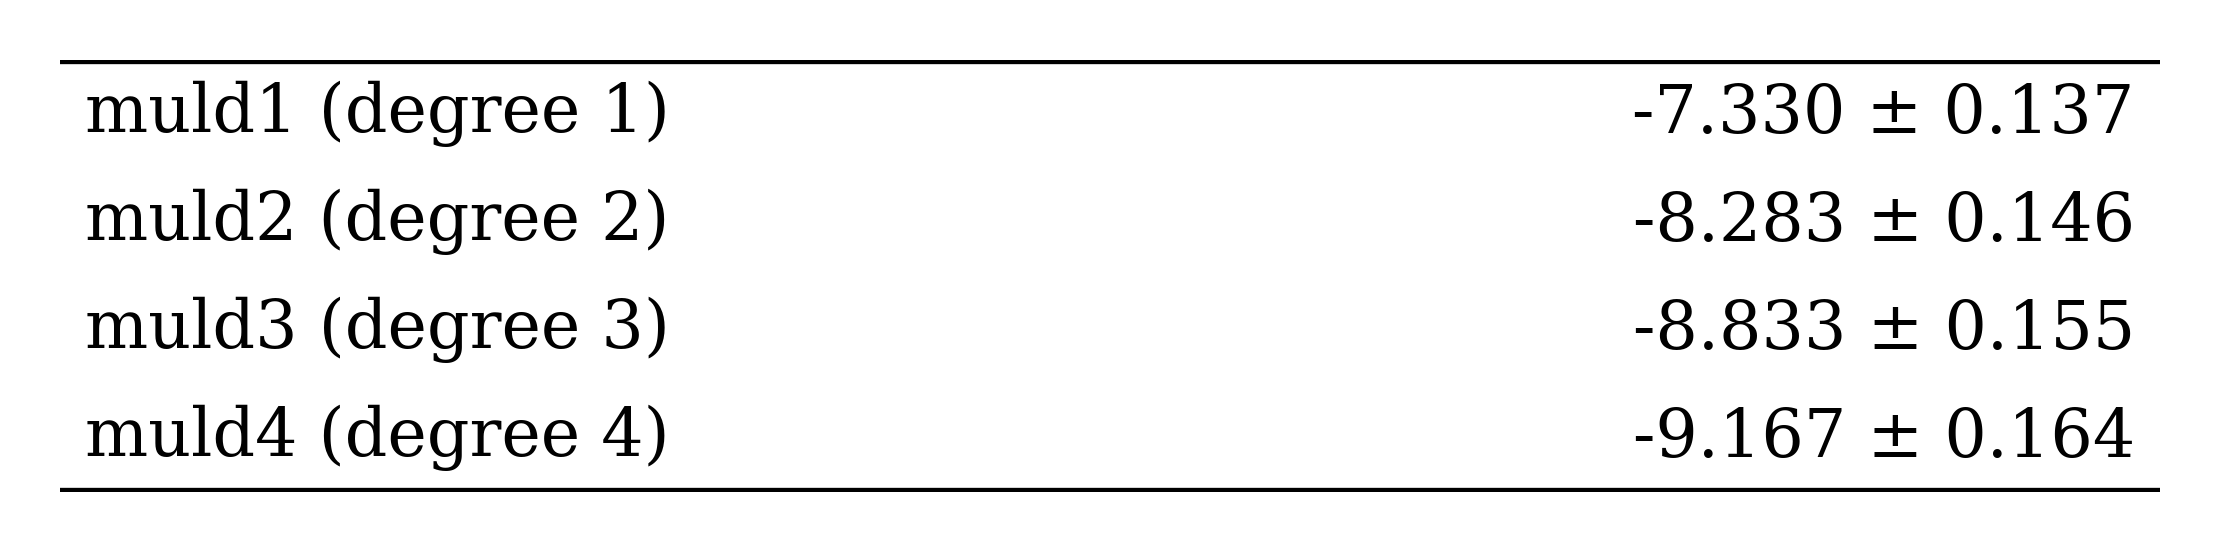

In [50]:
make_zne_order_table(PROCESSED_SIM_DATA["ZNE-mul-var"], output_dir=OUTPUT_DIR, filename_stem="zne_order_table", fontsize=8, row_height=0.18, fig_width=3.5, dpi=600)

---

# ZNE Cost Overhead

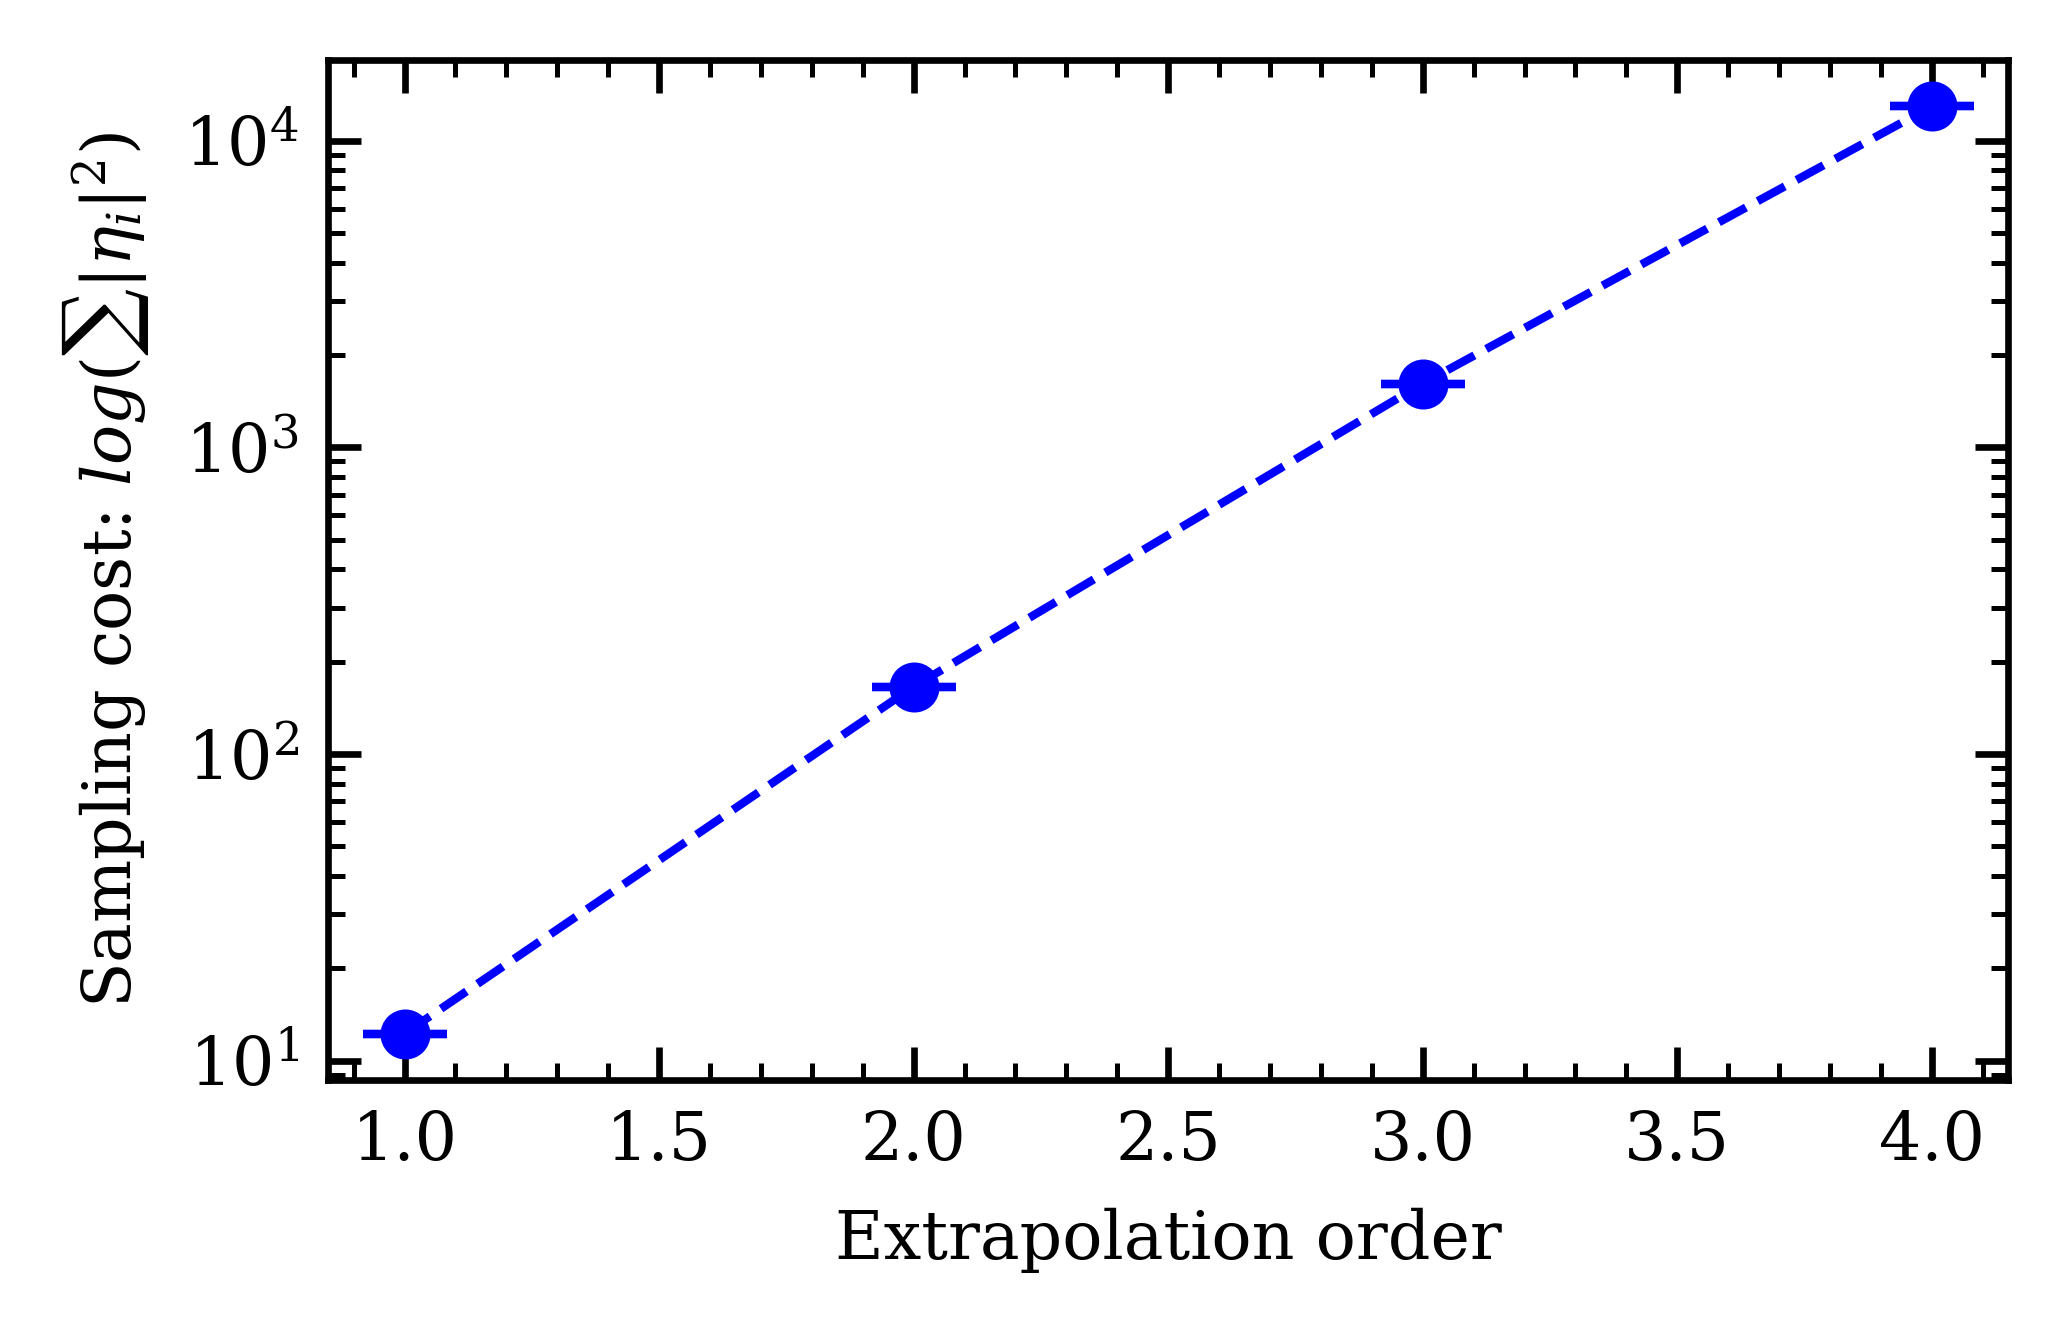

In [51]:
zne_cost_overhead = []
zne_cost_std = []
zne_order = []

# 1. Extract data using the correct key ["order"]
for item in PROCESSED_SIM_DATA["ZNE-mul-var"]:
    zne_cost_overhead.append(PROCESSED_SIM_DATA["ZNE-mul-var"][item]["cost_mean"])
    zne_cost_std.append(PROCESSED_SIM_DATA["ZNE-mul-var"][item]["cost_std"])
    zne_order.append(PROCESSED_SIM_DATA["ZNE-mul-var"][item]["order"])

# 2. Include zne_cost_std in the zip so all three arrays stay synchronized when sorted
sorted_data = sorted(zip(zne_order, zne_cost_overhead, zne_cost_std))
zne_order, zne_cost_overhead, zne_cost_std = zip(*sorted_data)

plt.figure(figsize=(3.5, 2.5))

# 3. Only use plt.errorbar (handles line, markers, and error bars together cleanly)
plt.errorbar(
    zne_order, zne_cost_overhead, yerr=zne_cost_std, 
    fmt='o', linestyle='--', color='#0000ff', 
    linewidth=1, capsize=5, markersize=5
)

# 4. FIX: Make the Y-axis compact using a logarithmic scale
plt.yscale('log')

plt.xlabel('Extrapolation order', fontsize=8)
plt.ylabel(r'Sampling cost: $log(\sum |\eta_i| ^2)$', fontsize=8)

# FIX: Set which='both' so the grid works seamlessly with major and minor log scale ticks
#plt.grid(True, linestyle='--', which='both', linewidth=0.5) 

plt.subplots_adjust(left=0.18, right=0.98, top=0.88, bottom=0.20)

#plt.title('Multi-Variate, All gates are noisy', fontsize=10)
# Ensure OUTPUT_DIR exists before saving
os.makedirs(OUTPUT_DIR, exist_ok=True)
plt.savefig(os.path.join(OUTPUT_DIR, "REVIEW--overhead_multivariate.eps"), format="eps", dpi=600)
plt.show()
plt.close()

---

# Circuit-dpeth Overhead

In [52]:
def load_redundant_gate_counts(filepath: str) -> dict:
    """
    Loads a _REDUNDANT.json file and extracts raw_gate_count for each
    noise detail entry.

    Returns
    -------
    dict with keys:
        "filepath"        : str  — source file path
        "raw_gate_counts" : list of dicts, one per noise_details entry,
                            each containing "identity_factors" and "raw_gate_count"
    """
    with open(filepath, "r") as f:
        data = json.load(f)

    noise_details = data["output"]["noise_details"]

    raw_gate_counts = [
        {
            "identity_factors": entry["identity_factors"],
            "raw_gate_count":   entry["raw_gate_count"],
        }
        for entry in noise_details
    ]

    return {
        "filepath":        filepath,
        "raw_gate_counts": raw_gate_counts,
    }

def load_all_redundant_gate_counts(folder: str) -> dict:
    """
    Scans each muldN subfolder under folder, reads the first _REDUNDANT.json
    found, and extracts its raw_gate_counts (all entries in a muld are identical).

    Returns
    -------
    dict keyed by subfolder name, e.g.:
        {
            "muld1": [
                {"identity_factors": [0,0,0,0], "raw_gate_count": {...}},
                ...
            ],
            "muld2": [...],
        }
    """
    results = {}
    for subfolder in sorted(os.listdir(folder)):
        subfolder_path = os.path.join(folder, subfolder)
        if not os.path.isdir(subfolder_path):
            continue
        for fname in sorted(os.listdir(subfolder_path)):
            if fname.endswith("_REDUNDANT.json"):
                fpath = os.path.join(subfolder_path, fname)
                entry = load_redundant_gate_counts(fpath)
                results[subfolder] = entry["raw_gate_counts"]
                break  # one file is enough

    return results

In [53]:
GATE_COUNTS = load_all_redundant_gate_counts(
    os.path.join(BASE_DIR, "ZNE", "ZNE-mul-var")
)

In [54]:
GATE_COUNTS["muld1"]

[{'identity_factors': [0, 0, 0, 0],
  'raw_gate_count': {'R': 4, 'CZ': 1, 'U': 1, 'Y': 0, 'total': 6}},
 {'identity_factors': [1, 1, 1, 1],
  'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 3, 'Y': 24, 'total': 42}},
 {'identity_factors': [1, 1, 1, 2],
  'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 3, 'Y': 40, 'total': 58}},
 {'identity_factors': [1, 1, 2, 1],
  'raw_gate_count': {'R': 12, 'CZ': 3, 'U': 5, 'Y': 48, 'total': 68}}]

In [55]:
ODD_SITES = 4
LAYERS = 30
def compute_depth(raw_gate_counts: list, ODD_SITES: int = ODD_SITES) -> float:
    """
    Computes circuit depth for a given muld as:
        depth = sum over all identity_factors of (R/2 + CZ + U + Y/4)

    Parameters
    ----------
    raw_gate_counts : list of dicts (as returned by load_all_redundant_gate_counts)
        Each dict has 'identity_factors' and 'raw_gate_count'.

    Returns
    -------
    float : total depth
    """
    depth = 0.0
    for entry in raw_gate_counts:
        gc = entry["raw_gate_count"]
        depth += (gc["R"] / 2 + gc["CZ"] + gc["U"] + gc["Y"] / ODD_SITES ) *LAYERS
        print(f"Identity factors: {entry['identity_factors']} -> Depth contribution: {(gc['R'] / 2 + gc['CZ'] + gc['U'] + gc['Y'] / ODD_SITES ) *LAYERS}")
    print("****")
    print("Total depth:", depth)
    print("****\n\n")
    return depth

In [56]:
depths = {muld: compute_depth(counts) for muld, counts in GATE_COUNTS.items()}

Identity factors: [0, 0, 0, 0] -> Depth contribution: 120.0
Identity factors: [1, 1, 1, 1] -> Depth contribution: 540.0
Identity factors: [1, 1, 1, 2] -> Depth contribution: 660.0
Identity factors: [1, 1, 2, 1] -> Depth contribution: 780.0
****
Total depth: 2100.0
****


Identity factors: [0, 0, 0, 0] -> Depth contribution: 120.0
Identity factors: [1, 1, 1, 1] -> Depth contribution: 540.0
Identity factors: [1, 1, 1, 2] -> Depth contribution: 660.0
Identity factors: [1, 1, 1, 3] -> Depth contribution: 780.0
Identity factors: [1, 1, 2, 1] -> Depth contribution: 780.0
Identity factors: [1, 1, 2, 2] -> Depth contribution: 1020.0
Identity factors: [1, 1, 3, 1] -> Depth contribution: 1020.0
Identity factors: [1, 2, 1, 1] -> Depth contribution: 600.0
Identity factors: [1, 2, 1, 2] -> Depth contribution: 720.0
Identity factors: [1, 2, 2, 1] -> Depth contribution: 840.0
****
Total depth: 7080.0
****


Identity factors: [0, 0, 0, 0] -> Depth contribution: 120.0
Identity factors: [1, 1, 1, 1] -> 

In [57]:
depths

{'muld1': 2100.0, 'muld2': 7080.0, 'muld3': 17220.0, 'muld4': 35460.0}

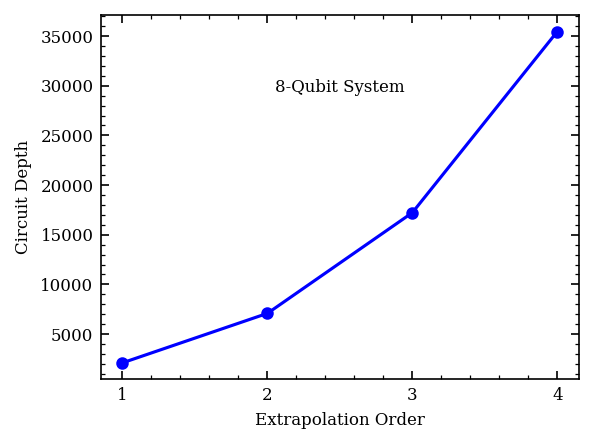

In [58]:
def plot_depth_vs_order(depths: dict, fig_width: float = 4.0, dpi: int = 150):
    """
    Plots circuit depth vs polynomial order.
    muldN maps to order N (muld1 → order 1, muld2 → order 2, ...).
    """
    orders = []
    depth_vals = []

    for muld, depth in sorted(depths.items(), key=lambda x: int(x[0].replace("muld", ""))):
        order = int(muld.replace("muld", ""))
        orders.append(order)
        depth_vals.append(depth)

    fig, ax = plt.subplots(figsize=(fig_width, fig_width * 0.75), dpi=dpi)

    ax.plot(orders, depth_vals, marker="o", linewidth=1.5, markersize=5, color="blue")

    ax.set_xlabel("Extrapolation Order", fontsize=8)
    ax.set_ylabel("Circuit Depth")
    ax.set_xticks(orders)
    ax.text(0.5, 0.8, "8-Qubit System", horizontalalignment='center',verticalalignment='center', transform=ax.transAxes)
    fig.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "REVIEW--all-gates-noisy-multivar-depth_vs_order.png"), format="png", dpi=dpi)
    plt.show()
    return fig

fig = plot_depth_vs_order(depths)
